# <h1 align = "center"> TAXI TRIP STATISTICAL ANALYSIS </h1>
# <h1 align = "center"> BY: LOVISH KOTHARAI </h1>

<img src = "https://static.vecteezy.com/system/resources/previews/006/071/212/non_2x/tourist-and-taxi-online-vector.jpg" width = "1400" height = "800">

# 🚕 NYC TAXI TRIP ANALYSIS

### Exploratory Data Analysis & Statistical Insights

## 📌 Dataset Overview

The dataset contains NYC taxi trip information such as pickup and drop-off details, passengers, distance, fare, tip, tolls, total amount, taxi color, payment method, and boroughs. The project focuses on exploring the dataset and identifying meaningful patterns and relationships within taxi trips.

## 🎯 Project Objective

To analyze NYC taxi trip data using Python and statistical techniques, perform Exploratory Data Analysis (EDA), and derive meaningful insights from the data.

## 🔍 Project Workflow

**0. Import Libraries**
Load the required Python libraries for data analysis and visualization.

**1. Load Dataset**
Import the Seaborn Taxis dataset and examine its structure.

**2. Data Cleaning**
Check and handle missing values, data types, and other data-quality issues.

**. Unique Value Analysis**
Identify unique values and understand the categories present in important columns.

**3. GroupBy Analysis**
Summarize and compare data using grouping and aggregation techniques.

**. Pivot Table Analysis**
Create pivot tables to analyze relationships between categorical and numerical variables.

**4. Exploratory Data Analysis (EDA)**

* **Univariate Analysis** — Analyze individual variables and their distributions.
* **Bivariate Analysis** — Study relationships between two variables.
* **Multivariate Analysis** — Analyze multiple variables together using different statistical visualizations.

**5. Final Observation**
Summarize the major findings, patterns, relationships, and statistical insights discovered during the analysis.



# <h1 align = "center"> STEP 0: IMPORTING LIBRARY </h1>

In [119]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Define color palettes for aesthetic and colorful visualizations
palette_hist = ['#4CAF50', '#FFC107', '#2196F3', '#FF5722', '#9C27B0']  # For histograms
palette_bar = sns.color_palette('Set2') # For bar plots
palette_scatter = sns.color_palette('pastel') # For scatter plots

In [115]:
# Define color palettes for aesthetic and colorful visualizations
palette_hist = ['#4CAF50', '#FFC107', '#2196F3', '#FF5722', '#9C27B0']  # For histograms
palette_bar = sns.color_palette('Set2') # For bar plots
palette_scatter = sns.color_palette('pastel') # For scatter plots

# <h1 align = "center"> STEP 1: LOAD DATASET </h1>

In [3]:
# LOAD DATASET

df = sns.load_dataset('taxis')

# Fill with mode() for every column:
columns = df.columns
for i in columns:
    df[i] = df[i].fillna(df[i].mode()[0])
df['pickup_hour'] = df['pickup'].dt.hour


In [4]:
# HEAD()
df.head(5)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,pickup_hour
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,20
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,16
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,17
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,1
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,13


In [4]:
# TAIL()
df.tail(5)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,pickup_hour
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan,9
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx,17
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn,22
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn,10
6432,2019-03-13 19:31:22,2019-03-13 19:48:02,1,3.85,15.0,3.36,0.0,20.16,green,credit card,Boerum Hill,Windsor Terrace,Brooklyn,Brooklyn,19


In [5]:
# CHECK INFORMATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6433 non-null   object        
 10  pickup_zone      6433 non-null   object        
 11  dropoff_zone     6433 non-null   object        
 12  pickup_borough   6433 non-null   object        
 13  dropoff_borough  6433 non-null   object        
 14  pickup_hour      6433 non-null   int32  

### Observations: DataFrame Information (`df.info()`)

1.  All columns have 6433 non-null entries, indicating no missing values after initial filling.
2.  The DataFrame contains a mix of `datetime64[ns]` for time, `float64` for continuous numerical data, `int32`/`int64` for discrete numerical data, and `object` for categorical strings.

In [6]:
# COLUMNS
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough', 'pickup_hour'],
      dtype='object')

### Observations: DataFrame Columns (`df.columns`)

1.  The DataFrame contains 15 columns, covering trip details (`pickup`, `dropoff`, `pickup_hour`), numerical metrics (`passengers`, `distance`, `fare`, `tip`, `tolls`, `total`), and categorical attributes (`color`, `payment`, `pickup_zone`, `dropoff_zone`, `pickup_borough`, `dropoff_borough`).
2.  The columns are well-named and descriptive, providing a clear understanding of the data content.
3.  The presence of both time-related and geographical columns allows for rich temporal and spatial analysis.

In [7]:
# CHECK STATS ON NUMERICAL VALUE
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,pickup_hour
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794,13.873465
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000,0.000000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000,10.000000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000,15.000000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000,19.000000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000,23.000000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570,6.069752


### Observations: Numerical Statistics (`df.describe()`)

1.  **Passengers:** The average number of passengers is 1.54, with a range from 0 to 6, and a median of 1, indicating mostly single-passenger trips.
2.  **Distance:** The average trip distance is 3.02 miles, but the maximum is 36.7 miles, showing a wide range and presence of long-haul trips.
3.  **Financial Metrics (Fare, Tip, Tolls, Total):** All show significant right-skewness, with means (e.g., fare ~$13, total ~$18.5) considerably higher than their medians, and large maximum values, suggesting some very expensive or long trips, and that a large portion of trips have low or no tips/tolls.
4.  **Pickup Hour:** The average pickup hour is 13.87 (around 2 PM), with a full range from 0 to 23, indicating taxi service throughout all hours of the day.

In [8]:
# CHECK STATS ON CATEGORICAL DATA
df.describe(include='object')

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6433,6433,6433,6433,6433
unique,2,2,194,203,4,5
top,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,5451,4621,256,290,5294,5251


### Observations: Categorical Statistics (`df.describe(include='object')`)

1.  **Taxi Color & Payment Method:** There are only 2 unique values for both 'color' (yellow, green) and 'payment' (credit card, cash), with 'yellow' (5451) and 'credit card' (4621) being the dominant categories respectively.
2.  **Pickup/Dropoff Zones:** There is a high cardinality for 'pickup_zone' (194 unique) and 'dropoff_zone' (203 unique), reflecting a large geographical area of operation, with 'Midtown Center' and 'Upper East Side North' being the most frequent.
3.  **Pickup/Dropoff Boroughs:** Pickups originate from 4 unique boroughs, and dropoffs occur in 5 unique boroughs, with 'Manhattan' being the most frequent for both (5294 pickups, 5251 dropoffs), highlighting its central role in taxi services.

# <h1 align = "center"> STEP 2: DATA CLEANING </h1>

In [9]:
# CHECK NULL VALUE
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


### OBSERVATION
- There is no null value.

In [10]:
# CHECK DUPLICATES
df.duplicated().sum()

np.int64(0)

### OBSERVATION
- There is no duplicate value.

# UNIQUE VALUE

In [14]:
# CHECK PICKUP
df.pickup.nunique()

6414

### OBSERVATION
- There are total 6414 uniquee values.

In [15]:
# CHECK DROPOFF
df.dropoff.nunique()

6425

### OBSERVATION
- There are total 6425 unique values.

In [16]:
# CHECK PASSENGERS
df.passengers.nunique()

7

In [17]:
df.passengers.unique()

array([1, 3, 0, 6, 5, 2, 4])

### Observation: Passengers Unique Values

- The dataset includes trips with 0 to 6 passengers, covering a range of group sizes.

In [18]:
# CHECK DISTANCE
df.distance.nunique()

1079

### OBSERVATION
- There are total 1079 unique distances.

In [23]:
# CHECK COLOR
df.color.nunique()

2

In [24]:
df.color.unique()

array(['yellow', 'green'], dtype=object)

### Observation: Color Unique Values

- The dataset contains two distinct taxi colors: 'yellow' and 'green'.

In [25]:
# CHECK PAYMENT
df.payment.nunique()

2

In [27]:
df.payment.unique()

array(['credit card', 'cash'], dtype=object)

### Observation: Payment Unique Values

- Payment methods are categorized into 'credit card' and 'cash'.

In [7]:
#  CHCECK PICKUP_ZONE
df.pickup_zone.nunique()

194

### OBSERVATION
- There arre total 194 unique pickup zones.

In [8]:
# CHECK DROPOFF_ZONE
df.dropoff_zone.nunique()

203

### OBSERVATION
- There are total 203 unique dropoff zones.

In [5]:
# CHECK PICKUP BOROUGH
df.pickup_borough.nunique()

4

In [6]:
df.pickup_borough.unique()

array(['Manhattan', 'Queens', 'Bronx', 'Brooklyn'], dtype=object)

### Observation: Pickup Borough Unique Values

- Pickups originate from Manhattan, Queens, Bronx, and Brooklyn.

In [10]:
# CHECK DROPOFF BOROUGH
df.dropoff_borough.nunique()

5

In [11]:
df.dropoff_borough.unique()

array(['Manhattan', 'Queens', 'Brooklyn', 'Bronx', 'Staten Island'],
      dtype=object)

### Observation: Dropoff Borough Unique Values

- Dropoffs occur in Manhattan, Queens, Brooklyn, Bronx, and Staten Island.

In [12]:
# CHECK PICKUP_HOUR
df.pickup_hour.nunique()

24

### OBSERVATION
- There are  total 24 unique pickup_hour.

# <h1 align="center"> 3. GROUPBY FUNCTION AND PIVOT TABALE </h1>

# GROUPBY FUNCTION

## SINGLE COLUMN ANALYSIS


In [14]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough', 'pickup_hour'],
      dtype='object')

In [21]:
df.groupby("passengers").size().sort_values(ascending=False)

,0
passengers,
1,4678
2,876
5,277
3,243
6,153
4,110
0,96


### Observations: Passenger Count Frequency

1.  The majority of trips are single-passenger, accounting for 4678 rides.
2.  Trips with 0, 4, and 6 passengers are the least frequent, suggesting specific use cases or data anomalies.
3.  There's a clear inverse relationship between passenger count and trip frequency.

In [23]:
df.groupby("distance").size().sort_values(ascending=False).head(10)

,0
distance,
0.8,131
1.0,118
0.9,116
0.7,108
1.2,107
1.1,106
0.6,104
1.3,97
1.6,90


### Observations: Trip Distance Frequency

1.  The most common trip distances are very short, predominantly between 0.6 and 1.6 miles.
2.  Trips of exactly 0.8 miles occur most frequently, with 131 instances.
3.  Longer distances are less frequent, as indicated by the top 10 being concentrated in small distances.

In [24]:
df.groupby("fare").size().sort_values(ascending=False).head(10)

,0
fare,
7.5,350
6.0,345
6.5,323
5.0,313
5.5,312
7.0,296
8.0,258
8.5,254
9.5,229


### Observations: Fare Frequency

1.  The most frequent fares are in the lower range, particularly between $4.50 and $9.50.
2.  The $7.50 fare is the most common, appearing 350 times.
3.  These low-to-mid range fares likely correspond to the short-distance trips previously observed.

In [25]:
df.groupby("tip").size().sort_values(ascending=False).head(10)

,0
tip,
0.00,2311
1.00,312
2.00,211
2.16,89
1.86,79
3.00,77
2.36,74
2.26,74
1.96,73


### Observations: Tip Amount Frequency

1.  A significant number of trips (2311) receive no tip at all.
2.  When tips are given, common amounts are $1.00 and $2.00.
3.  Tips are heavily concentrated at the lower end, indicating a general tendency for smaller tips.

In [26]:
df.groupby("tolls").size().sort_values(ascending=False).head(10)

,0
tolls,
0.00,6083
5.76,324
2.64,7
11.52,4
6.12,2
5.54,2
12.50,2
4.75,1
8.40,1


### Observations: Tolls Frequency

1.  The vast majority of trips (6083) incurred no tolls.
2.  When tolls are applied, $5.76 is the most common toll amount.
3.  Tolls are infrequent and typically occur in a few distinct values, suggesting specific routes or bridge/tunnel crossings.

In [27]:
df.groupby("total").size().sort_values(ascending=False).head(10)

,0
total,
9.3,146
11.3,129
11.8,122
9.8,121
10.3,121
8.8,118
12.3,101
8.3,100
10.8,98


### Observations: Total Amount Frequency

1.  The most frequent total amounts fall within a narrow range, predominantly between $8.30 and $12.80.
2.  A total amount of $9.30 is the most common, observed 146 times.
3.  These totals likely correspond to the frequent short-distance, low-fare trips.

In [28]:
df.groupby("color").size().sort_values(ascending=False)

,0
color,
yellow,5451
green,982


### Observations: Taxi Color Frequency

1.  Yellow cabs are significantly more prevalent than green cabs, with 5451 yellow cab trips.
2.  Green cabs account for a smaller portion of the dataset, with 982 trips.
3.  This suggests yellow cabs dominate the areas covered by this dataset.

In [29]:
df.groupby("payment").size().sort_values(ascending=False)

,0
payment,
credit card,4621
cash,1812


### Observations: Payment Method Frequency

1.  Credit card is the overwhelmingly preferred payment method, used in 4621 trips.
2.  Cash payments are less frequent, accounting for 1812 trips.
3.  This indicates a strong customer preference for cashless transactions.

In [30]:
df.groupby("pickup_zone").size().sort_values(ascending=False).head(10)

,0
pickup_zone,
Midtown Center,256
Upper East Side South,211
Penn Station/Madison Sq West,210
Clinton East,208
Midtown East,198
Upper East Side North,186
Times Sq/Theatre District,184
Union Sq,180
Lincoln Square East,177


### Observations: Pickup Zone Frequency (Top 10)

1.  Midtown Center is the most popular pickup zone, with 256 trips.
2.  All top 10 pickup zones are located in high-density areas, primarily Midtown and Upper East Side of Manhattan.
3.  This highlights the concentration of demand in specific commercial and residential hubs.

In [31]:
df.groupby("dropoff_zone").size().sort_values(ascending=False).head(10)

,0
dropoff_zone,
Upper East Side North,290
Murray Hill,220
Midtown Center,215
Upper East Side South,177
Midtown East,176
Times Sq/Theatre District,160
Lincoln Square East,156
Clinton East,151
East Village,150


### Observations: Dropoff Zone Frequency (Top 10)

1.  Upper East Side North is the most frequent dropoff zone, with 290 trips.
2.  Similar to pickup zones, the top dropoff zones are also concentrated in Manhattan's busy areas.
3.  This indicates high travel volume within and between these key Manhattan neighborhoods.

In [111]:
df.groupby("pickup_borough").size().sort_values(ascending=False)

,0
pickup_borough,
Manhattan,5294
Queens,657
Brooklyn,383
Bronx,99


### Observations: Pickup Borough Frequency

1.  Manhattan is the dominant pickup borough, accounting for 5294 trips.
2.  Queens, Brooklyn, and Bronx have significantly fewer pickups, in decreasing order of frequency.
3.  This distribution confirms Manhattan as the primary source of taxi demand.

In [33]:
df.groupby("dropoff_borough").size().sort_values(ascending=False)

,0
dropoff_borough,
Manhattan,5251
Queens,542
Brooklyn,501
Bronx,137
Staten Island,2


### Observations: Dropoff Borough Frequency

1.  Manhattan is also the most frequent dropoff borough, with 5251 trips.
2.  Staten Island is a rare dropoff destination, recording only 2 trips.
3.  This mirrors the pickup borough distribution, showing Manhattan as the central hub for taxi activity.

In [35]:
df.groupby("pickup_hour").size().sort_values(ascending=False).head(10)

,0
pickup_hour,
18,417
19,406
17,388
20,368
14,360
21,355
16,336
12,334
15,330


### Observations: Pickup Hour Frequency (Top 10)

1.  The peak pickup hours are concentrated in the evening, from 5 PM to 9 PM (hours 17-21).
2.  6 PM (hour 18) is the busiest hour, with 417 pickups.
3.  Demand remains high throughout the afternoon and evening, indicating a strong after-work and evening activity period.

## DOUBLE COLUMN ANALYSIS

In [37]:
df.groupby(["passengers","distance"]).size().sort_values(ascending=False)

passengers  distance
1           0.80        99
            1.00        90
            0.60        86
            1.20        85
            0.90        81
                        ..
            18.74        1
            18.71        1
            18.70        1
            18.62        1
            19.11        1
Length: 2001, dtype: int64

### Observations: Passengers and Distance Combinations

1.  Single-passenger trips (passenger=1) dominate the most frequent distance categories.
2.  Short distances (e.g., 0.8, 1.0, 0.6 miles) are most common for single-passenger trips.
3.  Very long distances appear only once for specific passenger-distance combinations, highlighting their rarity.

In [38]:
df.groupby(["passengers","fare"]).size().sort_values(ascending=False)

passengers  fare  
1           7.50      250
            6.00      249
            6.50      233
            5.50      233
            5.00      230
                     ... 
            23.32       1
6           12.50       1
            13.00       1
            59.50       1
            143.50      1
Length: 551, dtype: int64

### Observations: Passengers and Fare Combinations

1.  Single-passenger trips (passenger=1) are associated with the most frequent fare amounts.
2.  Common fares for single passengers are in the $5.00-$7.50 range.
3.  Some specific passenger-fare combinations, like a 6-passenger trip with a $143.50 fare, occur only once, indicating unique high-value or rare trips.

In [42]:
df.groupby(['passengers', 'total']).size().sort_values(ascending=False)

passengers  total
1           10.30    97
            9.30     95
            8.80     92
            11.30    89
            11.80    82
                     ..
6           46.87     1
            48.20     1
            51.96     1
            66.36     1
            68.56     1
Length: 1601, dtype: int64

### Observations: Passengers and Total Amount Combinations

1.  Single-passenger trips (passenger=1) account for the highest frequencies across various total amounts.
2.  The most common total amounts for single passengers are concentrated around $8.80 to $11.80.
3.  High total amounts, especially for higher passenger counts (e.g., 6 passengers), occur very rarely (only once for specific values).

In [43]:
df.groupby(["passengers","tip"]).size().sort_values(ascending=False)

passengers  tip 
1           0.00    1734
2           0.00     302
1           1.00     225
            2.00     160
5           0.00      88
                    ... 
0           1.70       1
            1.56       1
            1.55       1
            1.50       1
            1.38       1
Length: 978, dtype: int64

### Observations: Passengers and Tip Combinations

1.  The highest frequency is for zero tips, with 1734 single-passenger trips and 302 two-passenger trips receiving no tip.
2.  When tips are given, $1.00 and $2.00 are the most common amounts for single-passenger trips.
3.  Trips with 0 passengers also show instances of tips, suggesting specific contexts or data recording for these trips.

In [47]:
df.groupby(["color", "total"]).size().sort_values(ascending=False)

color   total
yellow  9.30     125
        11.30    114
        11.80    106
        9.80     104
        10.30     98
                ... 
green   34.55      1
        34.80      1
        34.99      1
        35.17      1
yellow  18.88      1
Length: 1085, dtype: int64

### Observations: Taxi Color and Total Amount Combinations

1.  Yellow cabs predominantly feature the most frequent total amounts, concentrated around $9.30 to $11.80.
2.  Green cabs appear less frequently in the top combinations, and often for higher, unique total amounts.
3.  This reflects the higher overall trip volume of yellow cabs and possibly different service patterns for green cabs.

In [48]:
df.groupby(["color", "payment"]).size().sort_values(ascending=False)

color   payment    
yellow  credit card    4039
        cash           1412
green   credit card     582
        cash            400
dtype: int64

### Observations: Taxi Color and Payment Type Combinations

1.  For both yellow and green cabs, credit card payments are significantly more frequent than cash payments.
2.  Yellow cabs show a much higher volume of both credit card (4039) and cash (1412) transactions compared to green cabs.
3.  The preference for credit card payments holds true regardless of taxi color.

In [49]:
df.groupby(["color", "pickup_zone"]).size().sort_values(ascending=False)

color   pickup_zone                 
yellow  Midtown Center                  252
        Upper East Side South           211
        Penn Station/Madison Sq West    210
        Clinton East                    208
        Midtown East                    198
                                       ... 
green   Crotona Park East                 1
yellow  Soundview/Castle Hill             1
        Soundview/Bruckner                1
        South Williamsburg                1
        Stuyvesant Heights                1
Length: 260, dtype: int64

### Observations: Taxi Color and Pickup Zone Combinations

1.  Yellow cabs dominate pickups in high-density Manhattan zones like Midtown Center (252 trips).
2.  Green cabs have a much lower presence in these top zones, with many appearing only once in less central areas.
3.  This highlights the operational focus of yellow cabs on central business districts and high-demand residential areas.

In [50]:
df.groupby(["color", "dropoff_zone"]).size().sort_values(ascending=False)

color   dropoff_zone             
yellow  Upper East Side North        271
        Murray Hill                  218
        Midtown Center               211
        Midtown East                 174
        Upper East Side South        170
                                    ... 
        Springfield Gardens South      1
green   Brooklyn Navy Yard             1
yellow  Stapleton                      1
        Van Cortlandt Village          1
green   Allerton/Pelham Gardens        1
Length: 355, dtype: int64

### Observations: Taxi Color and Dropoff Zone Combinations

1.  Yellow cabs also dominate dropoffs in key Manhattan areas, with Upper East Side North being the most frequent (271 trips).
2.  Green cab dropoffs are far less frequent in these top zones, often appearing for specific, less central locations.
3.  This confirms the strong presence of yellow cabs in the primary travel corridors of Manhattan.

In [53]:
df.groupby(["color", "pickup_borough"]).size()

color   pickup_borough
green   Bronx               83
        Brooklyn           313
        Manhattan          298
        Queens             288
yellow  Bronx               16
        Brooklyn            70
        Manhattan         4996
        Queens             369
dtype: int64

### Observations: Taxi Color and Pickup Borough Combinations

1.  Yellow cabs overwhelmingly dominate pickups in Manhattan (4996 trips).
2.  Green cabs have a stronger presence in Brooklyn (313 trips) and Bronx (83 trips) compared to yellow cabs in those boroughs.
3.  While green cabs have pickups in all boroughs, their numbers are much lower than yellow cabs, especially in Manhattan.

In [54]:
df.groupby(["color", "dropoff_borough"]).size()

color   dropoff_borough
green   Bronx                95
        Brooklyn            259
        Manhattan           352
        Queens              276
yellow  Bronx                42
        Brooklyn            242
        Manhattan          4899
        Queens              266
        Staten Island         2
dtype: int64

### Observations: Taxi Color and Dropoff Borough Combinations

1.  Yellow cabs are primarily associated with dropoffs in Manhattan (4899 trips).
2.  Green cabs show relatively higher dropoff numbers in the Bronx (95 trips) and Brooklyn (259 trips) compared to yellow cabs in those specific boroughs.
3.  Staten Island recorded only 2 yellow cab dropoffs, indicating minimal service to that borough.

# PIVOT TABLE

In [124]:
display(df.pivot_table(
    index='passengers',
    values=['distance', 'fare', 'tip', 'tolls', 'total'],
    aggfunc='sum'
).style.background_gradient(cmap='viridis').format('{:.0f}'))

,distance,fare,tip,tolls,total
passengers,,,,,
0,284,1222,230,52,1821
1,14124,60987,8992,1493,85737
2,2609,11534,1843,282,16564
3,762,3406,538,107,4875
4,323,1434,251,35,2097
5,821,3482,563,75,5025
6,534,2148,314,50,3007


### Observations: Pivot Table - Passengers vs. Aggregated Values

1.  **Highest Aggregates for Single Passengers:** Trips with 1 passenger consistently show the highest total distance (14124.03 miles), fare (60987.37), tip (8992.47), tolls (1492.58), and total amount (85736.77). This is expected given that single-passenger trips are the most frequent.
2.  **Lowest Values for Zero Passengers:** Trips with 0 passengers, while being the least frequent after 4 passengers, show significant total values across all metrics (e.g., total distance 284.20 miles, total fare 1222.50). This category warrants further investigation to understand its nature.
3.  **Proportional Decrease:** As the number of passengers increases from 1 to 6, the aggregated values generally decrease, indicating fewer total trips or shorter distances/fares for larger groups.
4.  **Overall Insight:** The data strongly suggests that the business primarily caters to individual travelers, who contribute the most to all revenue-related metrics.

In [125]:
display(df.pivot_table(
    index='color',
    columns= ['pickup_borough', "dropoff_borough"],
    values='total',
    aggfunc='sum'
).style.background_gradient(cmap='Purples').format('{:.0f}'))

### Observations: Pivot Table - Taxi Color vs. Pickup/Dropoff Borough (Total Amount)

1.  **Yellow Cab Dominance in Manhattan:** Yellow cabs show an overwhelming dominance in total earnings, especially for trips within Manhattan (pickup Manhattan, dropoff Manhattan: 71272.11). This highlights Manhattan as the core market for yellow taxis.
2.  **Green Cab Niche:** Green cabs have higher total amounts in certain non-Manhattan corridors compared to yellow cabs in those same corridors. For instance, green cabs have a higher total amount for Bronx-Bronx trips (923.50) compared to yellow cabs (109.30), and Brooklyn-Brooklyn trips (3330.59) vs yellow cabs (533.22).
3.  **Cross-Borough Revenue:** Significant cross-borough revenue exists, particularly from Manhattan to Queens (Yellow: 7476.96 total) and from Queens to Manhattan (Yellow: 11198.03 total).
4.  **Staten Island Service Gap:** Only yellow cabs recorded trips to Staten Island (pickup Manhattan, dropoff Staten Island: 153.73), suggesting a potential service gap or operational limitation for green cabs in this area.
5.  **Data Gaps:** Several `NaN` values indicate combinations of pickup/dropoff boroughs where no trips for a specific taxi color were recorded in the dataset, which is expected due to the operational zones of different taxi colors.

In [126]:
display(df.pivot_table(
    index='pickup_borough',
    columns='dropoff_borough',
    values='total',
    aggfunc='sum'
).style.background_gradient(cmap='viridis').format('{:.0f}'))

dropoff_borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
pickup_borough,,,,,
Bronx,1033,236,799,186,nan
Brooklyn,324,3864,2212,968,nan
Manhattan,1490,4921,74420,7719,154
Queens,588,2626,12362,5226,nan


### Observations: Pivot Table - Pickup Borough vs. Dropoff Borough (Total Amount)

1.  **Manhattan-Centric Revenue:** Manhattan is by far the highest revenue-generating borough, especially for trips originating and ending within Manhattan, contributing 74419.74 to the total amount.
2.  **Significant Cross-Borough Travel:** There's substantial revenue from cross-borough trips, notably from Manhattan to Queens (7718.92) and Manhattan to Brooklyn (4921.12), and from Queens to Manhattan (12361.50).
3.  **Queens as a High-Value Destination:** Queens appears to be a significant destination from Manhattan and also generates considerable internal revenue (5225.79).
4.  **Lower Volume Boroughs:** Bronx and Brooklyn generate comparatively lower total amounts, both for intra-borough travel and travel to/from other boroughs. For example, Bronx-Bronx trips total 1032.80, and Brooklyn-Brooklyn total 3863.81.
5.  **Staten Island Limited Reach:** Only trips originating from Manhattan recorded a dropoff in Staten Island (153.73), indicating a very limited service to this borough from the other major pickup boroughs in the dataset.

In [127]:
display(df.pivot_table(
    index=['payment', 'color'],
    columns=['pickup_borough', 'dropoff_borough'],
    values='total',
    aggfunc='sum'
).style.background_gradient(cmap='coolwarm').format('{:.0f}'))

### Observations: Pivot Table - Payment, Color vs. Pickup/Dropoff Borough (Total Amount)

1.  **Credit Card Dominance:** Credit card payments consistently account for a much larger proportion of the total amount across almost all borough combinations and taxi colors, reinforcing the preference for digital payments.
2.  **Yellow Cab - Credit Card - Manhattan:** The highest revenue stream is from yellow cabs paid by credit card for trips within Manhattan (pickup Manhattan, dropoff Manhattan: 55997.69), which aligns with previous observations about yellow cab and Manhattan dominance.
3.  **Green Cab - Cash in Brooklyn/Bronx:** Green cabs show a relatively higher contribution from cash payments in non-Manhattan boroughs, such as Brooklyn-Brooklyn (cash: 971.80 vs credit card: $2358.79) and Bronx-Bronx (cash: 174.10 vs credit card: 749.40), compared to yellow cabs in those same areas.
4.  **Cross-Borough Payment Patterns:** For significant cross-borough routes like Queens to Manhattan, credit card payments via yellow cabs generate significantly more revenue (9128.39) than cash payments (2069.64).
5.  **Strategic Implications:** This detailed breakdown by payment method and taxi color across routes provides insights for optimizing payment infrastructure, targeted promotions (e.g., cashless incentives), and understanding the financial behavior of different taxi market segments.

In [88]:
df['pickup_hour'] = df['pickup'].dt.hour

In [128]:
display(df.pivot_table(
    index='pickup_hour',
    columns=['pickup_borough', 'dropoff_borough'],
    values='total',
    aggfunc='count',
    fill_value=0
).style.background_gradient(cmap='magma').format('{:.0f}'))

### Observations: Pivot Table - Pickup Hour vs. Pickup/Dropoff Borough (Trip Count)

1.  **Manhattan Domination Throughout the Day:** Manhattan (pickup and dropoff Manhattan) consistently shows the highest number of trips across nearly all hours, peaking in the evening, confirming its status as the busiest taxi hub.
2.  **Evening Peak Across Boroughs:** The evening hours (17-20) show a general increase in trip counts across most active pickup/dropoff borough combinations, indicating a universal evening rush.
3.  **Early Morning Activity:** While overall trip counts are low in the early morning (1-5 AM), Manhattan still maintains a significant number of trips during these hours (e.g., 134 Manhattan-Manhattan trips at 0 AM), likely catering to late-night entertainment or early airport runs.
4.  **Cross-Borough Commute Patterns:** Specific cross-borough routes, such as Manhattan to Queens or Brooklyn, also show increased activity during peak commute hours, reflecting commuter movements.
5.  **Strategic Scheduling:** This granular hourly data is invaluable for dynamic driver scheduling, especially for positioning taxis in high-demand boroughs during peak hours to maximize availability and reduce wait times.

# <h1 align = "center"> 4. EDA(EXPLORATORY DATA  ANALYSIS) </h1>

## Choosing the Right Visualization (Bivariate Analysis)

### 🔢 Numerical vs Numerical (Num–Num)
**Goal:** Understand relationship, trend, correlation

**Use:**
- Scatter Plot → primary choice  
- Scatter + Regression Line → to see trend  
- Hexbin / Density Plot → for large datasets  

**Example:** distance vs fare

---

### 🔤 Categorical vs Categorical (Cat–Cat)
**Goal:** Compare distributions, proportions, relationships

**Use:**
- Cross-tabulation (table) → base analysis  
- Stacked Bar Chart → proportions across categories  
- Heatmap → better pattern visibility (large categories)  

**Example:** payment type vs pickup borough

---

### 🔢🔤 Numerical vs Categorical (Num–Cat)
**Goal:** Compare distributions of numerical values across categories

**Use:**
- Box Plot → best overall (spread + outliers)  
- Violin Plot → distribution shape  
- Bar Plot (mean/median) → summary comparison  

**Example:** fare across passenger count

---

### ⚠️ Quick Rules
- Relationship → Scatter  
- Distribution comparison → Box/Violin  
- Proportions → Stacked Bar  
- Dense data → Hexbin / Heatmap

## 🔵 UNIVARIATE ANALYSIS

### 1. Distribution of Trip Distance

**Question:** 👉 Are most trips short or long?

**Graph:** Histogram

**Business Insight:** Helps pricing strategy & fuel planning

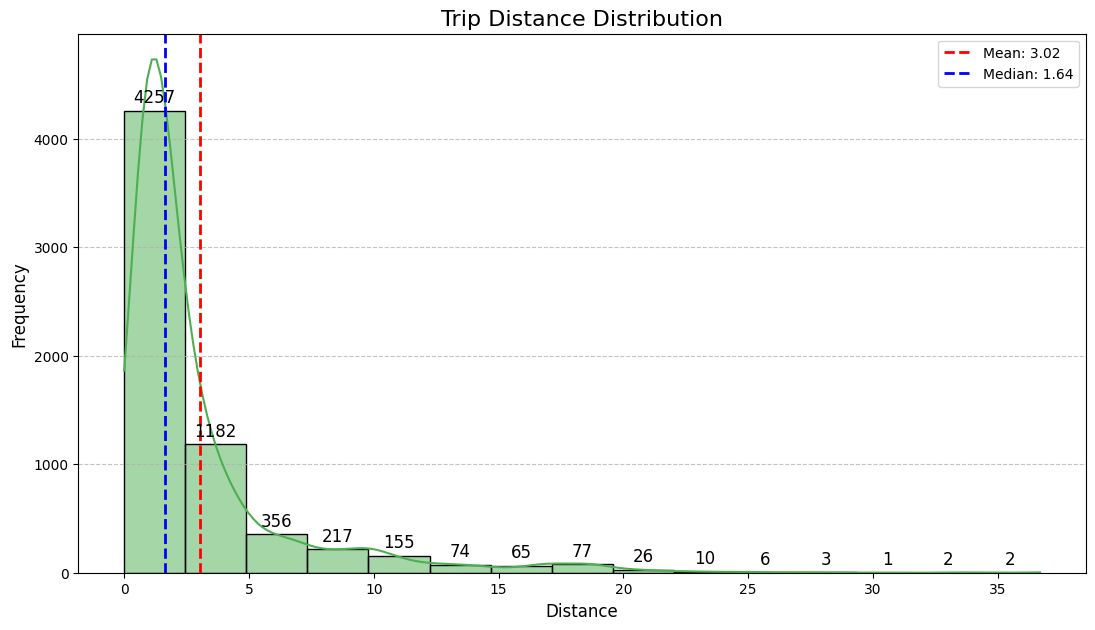

In [214]:
plt.figure(figsize=(13,7))
ax = sns.histplot(df['distance'], bins=15, kde=True, color=sns.color_palette(palette_hist)[0])
plt.axvline(df['distance'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["distance"].mean():.2f}')
plt.axvline(df['distance'].median(), color='blue', linestyle='dashed', linewidth=2, label=f'Median: {df["distance"].median():.2f}')
plt.title('Trip Distance Distribution', fontsize=16)
plt.xlabel('Distance', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.legend()

# Add annotations to each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only annotate bars with a height greater than 0
        ax.annotate(f'{int(height)}',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, color='black')

plt.show()

### Observations: Trip Distance Distribution

1.  **Highest Frequency:** The vast majority of trips cover very short distances, peaking with **4257 trips** in the **0-2 mile range**. Trips of **35 miles** are the longest observed, with only **2 instances**.
2.  **Right-Skewed:** The distribution is heavily right-skewed, indicating fewer long-distance trips. The **mean distance (3.02 miles)** is greater than the **median distance (1.64 miles)**, confirming this skewness.
3.  **Outliers:** There are a few trips with exceptionally long distances, such as those up to **36.7 miles** with very low frequencies, suggesting possible outliers or special service types.
4.  **Business Insight:** This pattern is critical for optimizing pricing models (e.g., minimum fares, per-mile rates for short vs. long distances) and driver routing, as many drivers will primarily complete short trips. The difference between mean and median highlights that average trip distance is pulled up by a few longer trips.

### 2. Distribution of Fare

**Question:** 👉 What is the typical fare range?

**Insight:** Identify cheap vs expensive rides

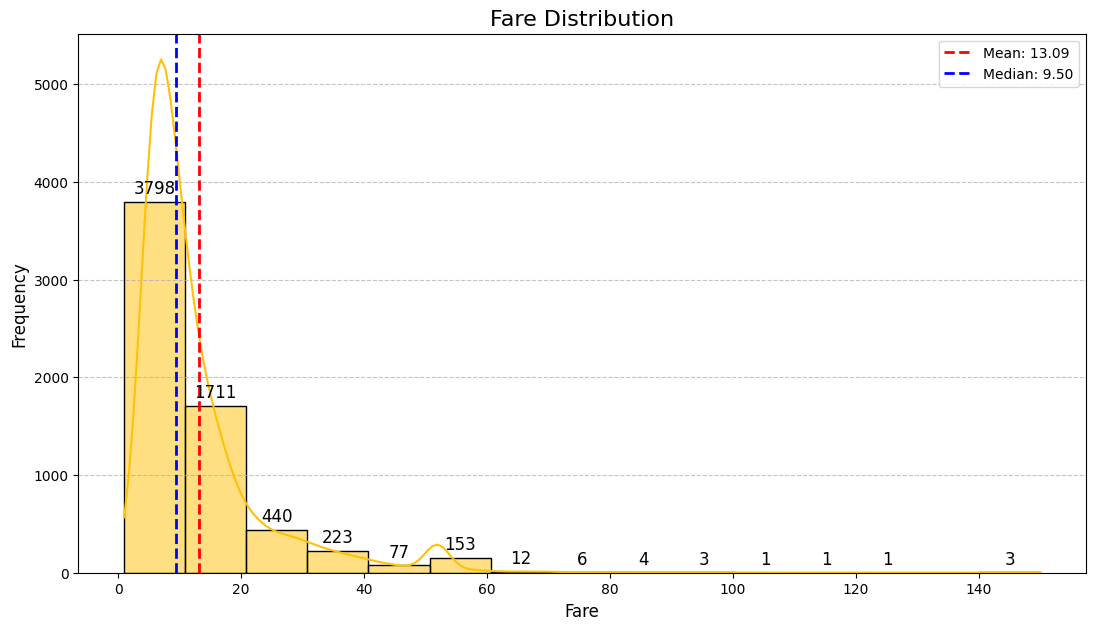

In [215]:
plt.figure(figsize=(13, 7))
ax = sns.histplot(df['fare'], bins=15, kde=True, color=sns.color_palette(palette_hist)[1])
plt.axvline(df['fare'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["fare"].mean():.2f}')
plt.axvline(df['fare'].median(), color='blue', linestyle='dashed', linewidth=2, label=f'Median: {df["fare"].median():.2f}')
plt.title('Fare Distribution', fontsize=16)
plt.xlabel('Fare', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.legend()

# Add annotations to each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only annotate bars with a height greater than 0
        ax.annotate(f'{int(height)}',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, color='black')

plt.show()

### Observations: Fare Distribution

1.  **Most Common Fare:** The highest frequency of fares falls within the lower range, with **3798 trips** in the **$0-$5.50 fare range**. The lowest recorded fare is **$1.00**, while the highest is **$150.00**.
2.  **Right-Skewed:** Similar to distance, the fare distribution is right-skewed. The **mean fare ($13.09)** is noticeably higher than the **median fare ($9.50)**, indicating that a few higher fares pull the average up.
3.  **Spread:** While most fares are low, there's a considerable spread, with some trips generating significantly higher revenue, reaching up to the maximum fare of **$150.00**.
4.  **Business Insight:** Understanding this distribution helps in setting competitive base fares and identifying premium service opportunities, considering that a significant portion of rides are relatively inexpensive.

### 3. Passenger Count Distribution

**Question:** 👉 How many passengers usually travel?

**Insight:** Helps decide vehicle type demand

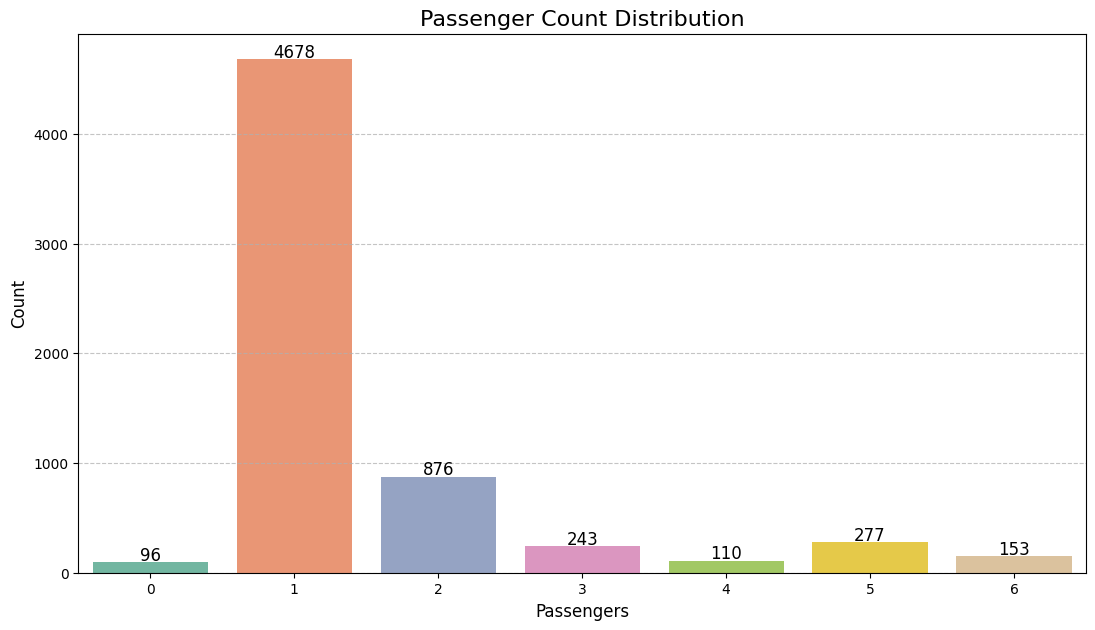

In [184]:
plt.figure(figsize=(13, 7))
ax = sns.countplot(x=df['passengers'], palette=palette_bar)
plt.title('Passenger Count Distribution', fontsize=16)
plt.xlabel('Passengers', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')

# Add annotations
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Observations: Passenger Count Distribution

1.  **Dominant Group:** Single-passenger trips (1 passenger) are by far the most common, accounting for **4678 rides**.
2.  **Fewer Groups:** The number of trips decreases significantly as the passenger count increases. The **lowest frequency is for 0 passengers (96 trips)** and **4 passengers (110 trips)**.
3.  **Zero Passengers:** A small number of trips show '0' passengers, which might indicate data entry errors or specific scenarios like driver-only trips (e.g., repositioning, car maintenance).
4.  **Improvement:** Investigating the '0' passenger count could help clean data or reveal operational aspects. This also suggests that vehicle capacity is rarely fully utilized.

### 4. Payment Method Distribution

**Question:** 👉 Which payment method is most used?

**Insight:** Digital vs cash usage

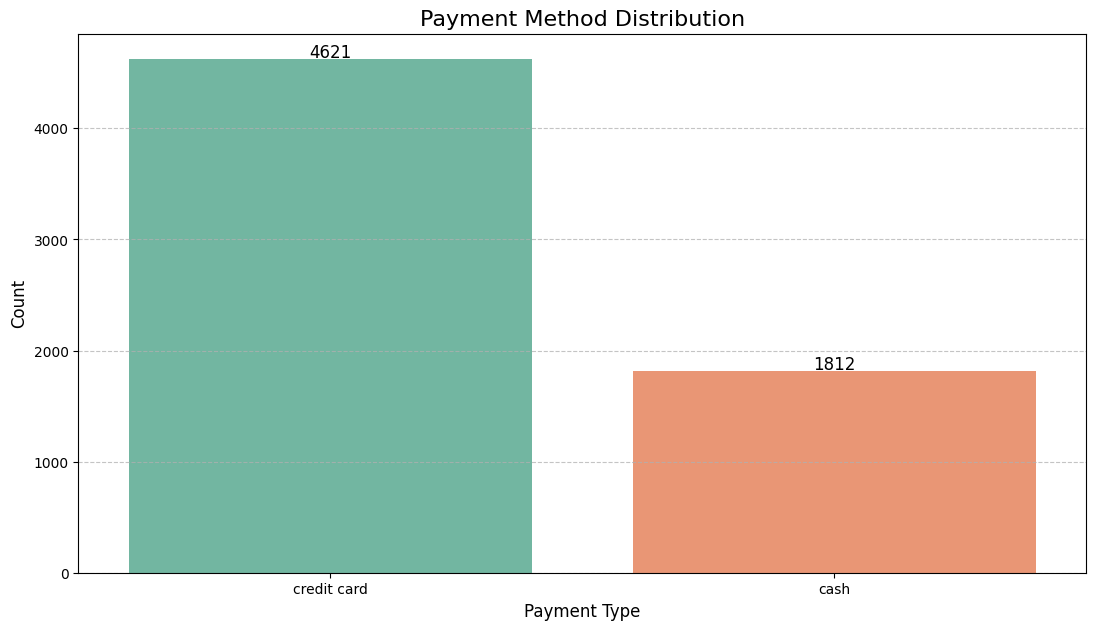

In [186]:
plt.figure(figsize=(13 , 7))
ax = sns.countplot(x='payment', data=df, palette=palette_bar)
plt.title('Payment Method Distribution', fontsize=16)
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')

# Add annotations
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Observations: Payment Method Distribution

1.  **Preferred Method:** Credit card payments are significantly more popular than cash payments, with **4621 trips** using credit cards.
2.  **Digital Dominance:** This indicates a strong preference for digital transactions.
3.  **Business Insight:** Focusing on optimizing the credit card payment process and integrating various digital payment options could enhance customer experience and operational efficiency.
4.  **Lowest Usage:** Cash payments are less than half the volume of credit card payments, recorded in **1812 trips**.

### 5. Taxi Color Distribution

**Question:** 👉 Which taxi type is used more?

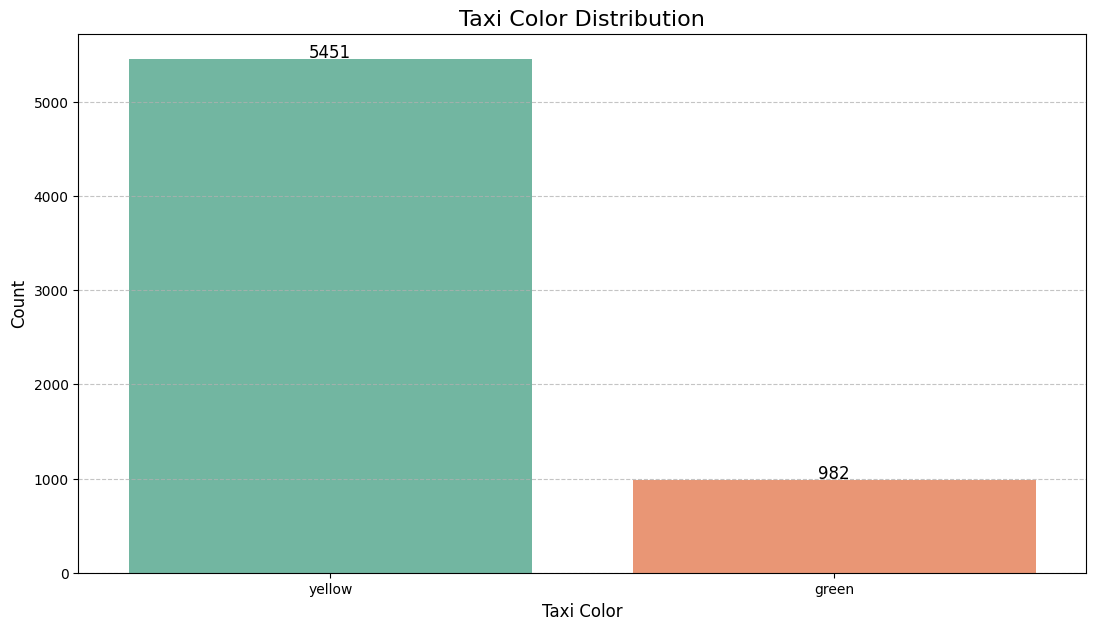

In [187]:
plt.figure(figsize=(13, 7))
ax = sns.countplot(x='color', data=df, palette=palette_bar)
plt.title('Taxi Color Distribution', fontsize=16)
plt.xlabel('Taxi Color', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')

# Add annotations
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Observations: Taxi Color Distribution

1.  **Dominant Color:** Yellow taxis are overwhelmingly more prevalent than green taxis, with **5451 yellow cab trips**.
2.  **Market Share:** Yellow taxis hold a significantly larger market share in the dataset.
3.  **Insight:** This suggests that the dataset might predominantly feature rides from areas or services where yellow cabs are the primary mode of transport, or that yellow cabs simply outnumber green cabs in general operation. The **lowest count is for green cabs, with 982 trips**.
4.  **Improvement:** Understanding the context of 'yellow' vs 'green' (e.g., operating zones) would be beneficial to interpret this disparity.

### 6. Tip Distribution

**Question:** 👉 Do customers usually tip?

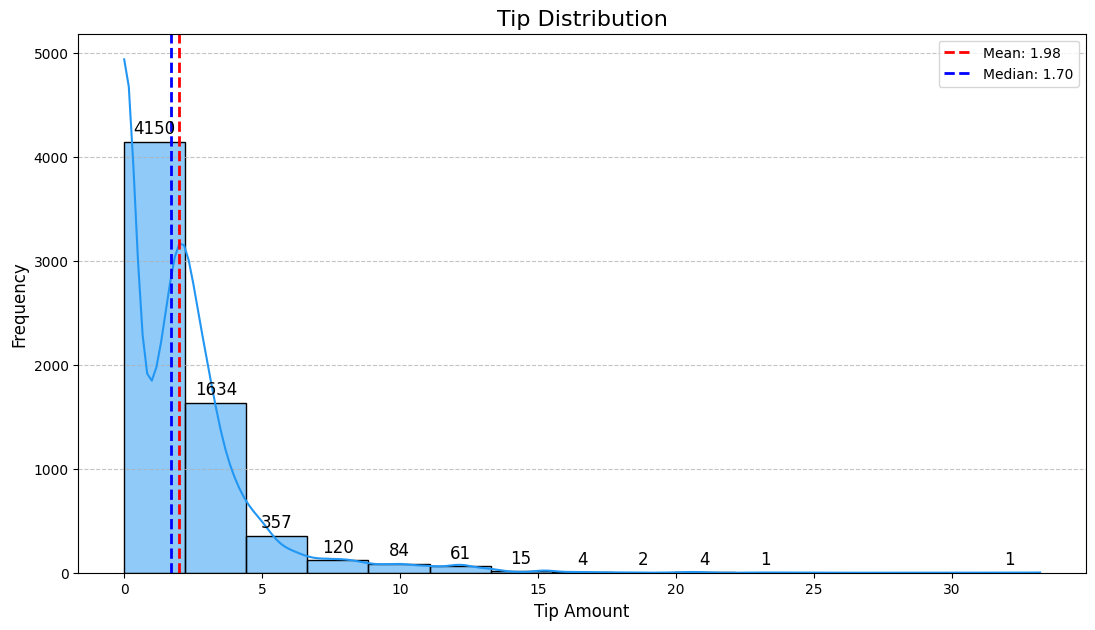

In [188]:
plt.figure(figsize=(13, 7))
ax = sns.histplot(df['tip'], bins=15, kde=True, color=sns.color_palette(palette_hist)[2])
plt.axvline(df['tip'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["tip"].mean():.2f}')
plt.axvline(df['tip'].median(), color='blue', linestyle='dashed', linewidth=2, label=f'Median: {df["tip"].median():.2f}')
plt.title('Tip Distribution', fontsize=16)
plt.xlabel('Tip Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.legend()

# Add annotations to each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only annotate bars with a height greater than 0
        ax.annotate(f'{int(height)}',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3), # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, color='black')

plt.show()

### Observations: Tip Distribution

1.  **No Tip/Low Tip:** A substantial portion of trips result in zero or very low tips, with **4150 instances** where tips are between **$0-$2**. The **median tip is $1.70**, while the **mean tip is $1.98**, showing a slight positive skew due to some larger tips.
2.  **Right-Skewed:** The distribution is highly right-skewed, with most tips concentrated at the lower end and fewer instances of high tips.
3.  **Highest Tips:** While rare, some customers offer very generous tips, with the highest recorded tip being **$33.20**.
4.  **Improvement:** Analyzing factors that correlate with higher tips (e.g., service quality, trip duration, total fare) could help drivers increase their earnings, especially given that many trips receive no tips.

### 7. Pickup Hour Distribution

**Question:** 👉 When are rides most frequent?

**Insight:** Peak hours

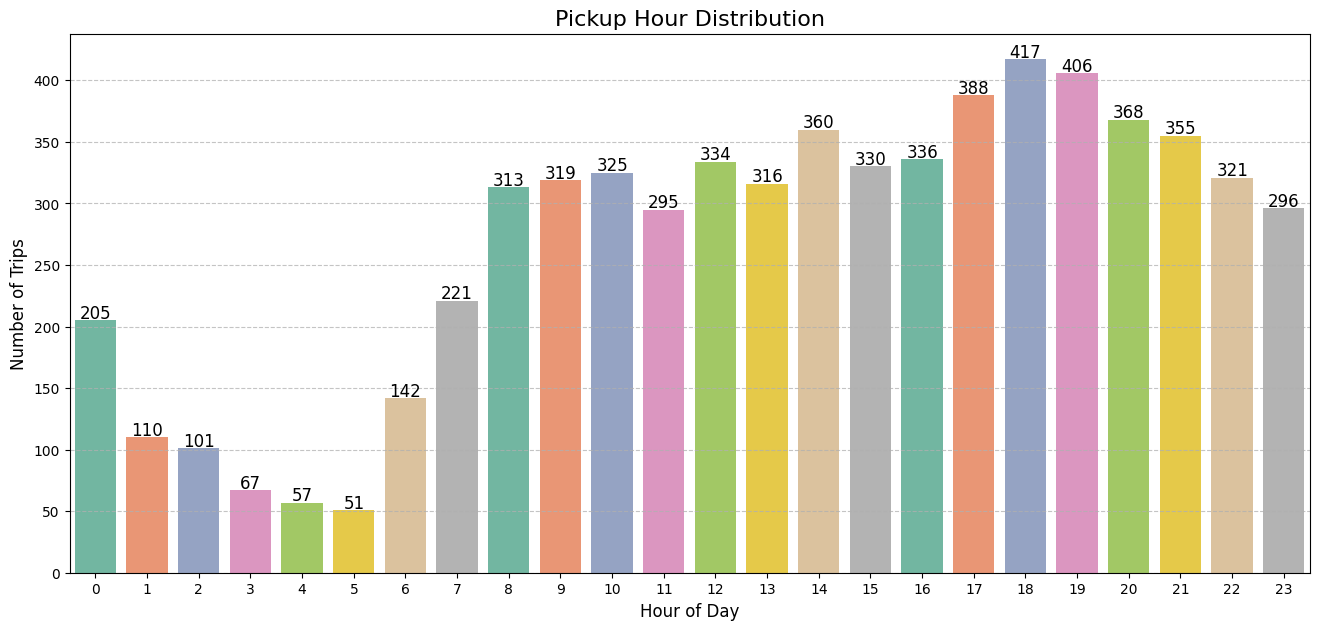

In [190]:
plt.figure(figsize=(16, 7))
ax = sns.barplot(x=df['pickup_hour'].value_counts().sort_index().index, y=df['pickup_hour'].value_counts().sort_index().values, palette=palette_bar)
plt.title('Pickup Hour Distribution', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')

# Add annotations
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Observations: Pickup Hour Distribution

1.  **Peak Hours:** The highest number of pickups occurs in the evening, particularly between **5 PM and 8 PM (hours 17-20)**. **Hour 18 (417 trips)** and **Hour 19 (406 trips)** are the busiest.
2.  **Lowest Activity:** There's a significant drop in activity during the early morning hours, with **Hour 4 showing the lowest pickups (51 trips)**.
3.  **Morning Rush:** A noticeable increase in pickups starts around 6 AM and continues through the morning.
4.  **Business Insight:** This pattern is crucial for dynamic pricing, driver scheduling, and resource allocation to meet demand efficiently during peak and off-peak hours.

### 8. Pickup Borough Distribution

**Question:** 👉 Which area has most pickups?

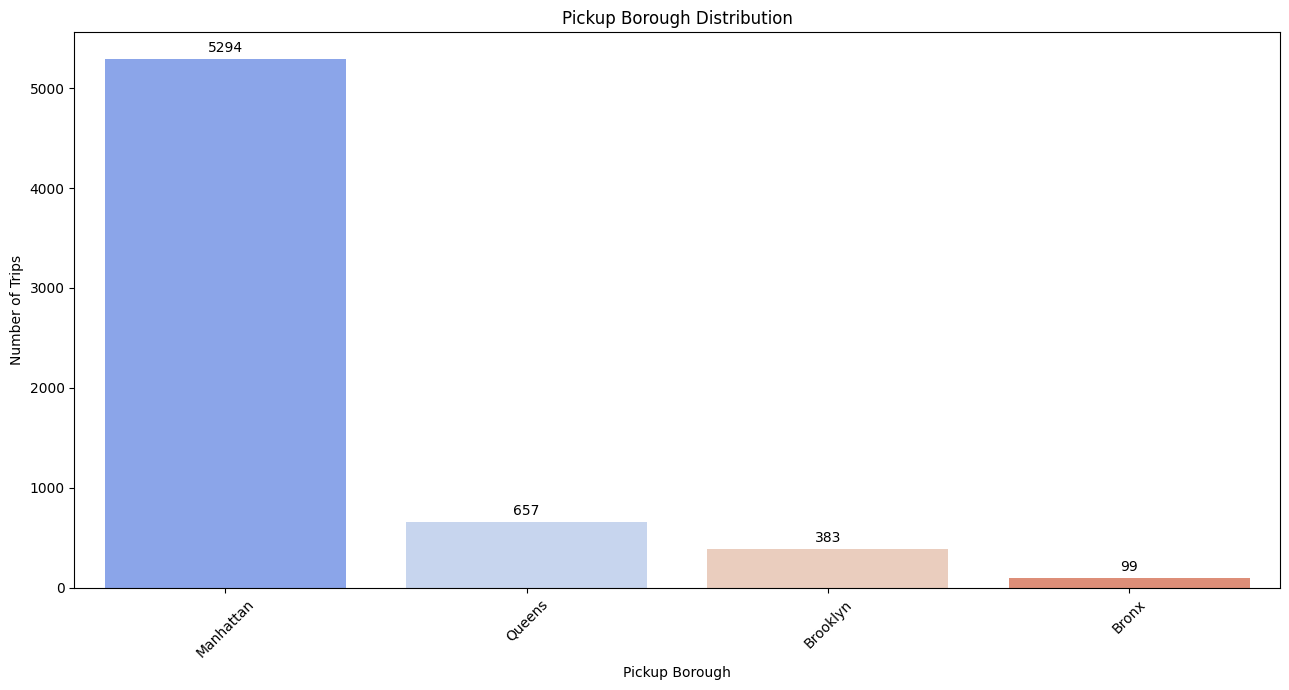

In [194]:
plt.figure(figsize=(13, 7))

pickup_count = df['pickup_borough'].value_counts()

ax = sns.barplot(
    x=pickup_count.index,
    y=pickup_count.values,
    palette = "coolwarm"
)

plt.title('Pickup Borough Distribution')
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

### Observations: Pickup Borough Distribution

1.  **Dominant Borough:** Manhattan accounts for the overwhelming majority of taxi pickups, with **5294 trips**.
2.  **Second Highest:** Queens is the second busiest, but with significantly fewer pickups compared to Manhattan, recording **657 trips**.
3.  **Lowest Activity:** Bronx has the fewest pickups, with only **99 trips**, suggesting lower demand or alternative transportation options in that area.
4.  **Improvement:** This information can guide fleet deployment and marketing efforts, potentially exploring reasons for lower pickup rates in less active boroughs.

## 🔴 BIVARIATE ANALYSIS

### 1. Distance vs Fare

**Question:** 👉 Does fare increase with distance?

**Why:** Relationship between two numeric variables

**Insight:** Pricing validation

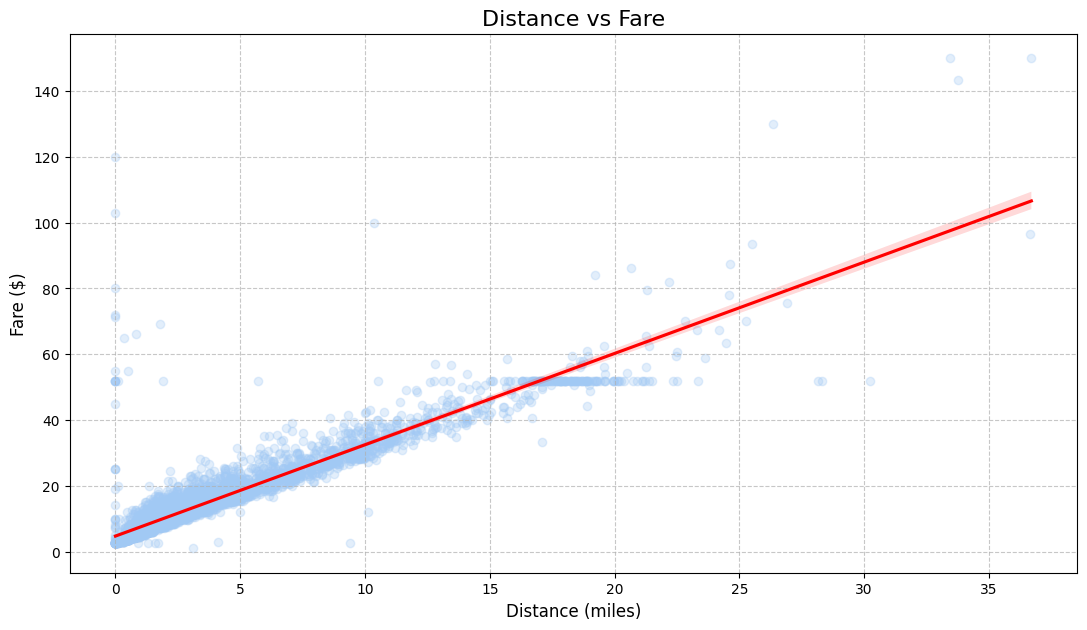

In [195]:
plt.figure(figsize=(13, 7))
sns.regplot(x='distance', y='fare', data=df, scatter_kws={'alpha':0.3, 'color':sns.color_palette(palette_scatter)[0]}, line_kws={'color':'red'})
plt.title('Distance vs Fare', fontsize=16)
plt.xlabel('Distance (miles)', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Observations: Distance vs Fare

1.  **Strong Positive Linear Relationship:** The **regression line** clearly indicates a strong positive linear relationship, meaning that as trip distance increases, the fare also consistently increases. This validates the fundamental distance-based pricing model, with fares reaching up to **150.00** for longer trips (up to **36.7 miles**).
2.  **Variations around the Line:** While the general trend is linear, there's noticeable scatter around the regression line. This suggests that other factors besides distance (e.g., traffic, tolls, time of day, base fare) also influence the final fare amount.
3.  **Outliers:** There are some significant outliers, where short distances correspond to unusually high fares, or very long distances have fares that deviate from the expected trend, possibly indicating special circumstances or charges. For example, some trips with distances close to **0 miles** still incur a minimum fare of **1.00**.
4.  **Insight:** The regression line provides a clear average pricing structure, but the scatter highlights the variability and influence of additional cost components, important for pricing strategy and understanding fare discrepancies.

### 2. Distance vs Total Amount

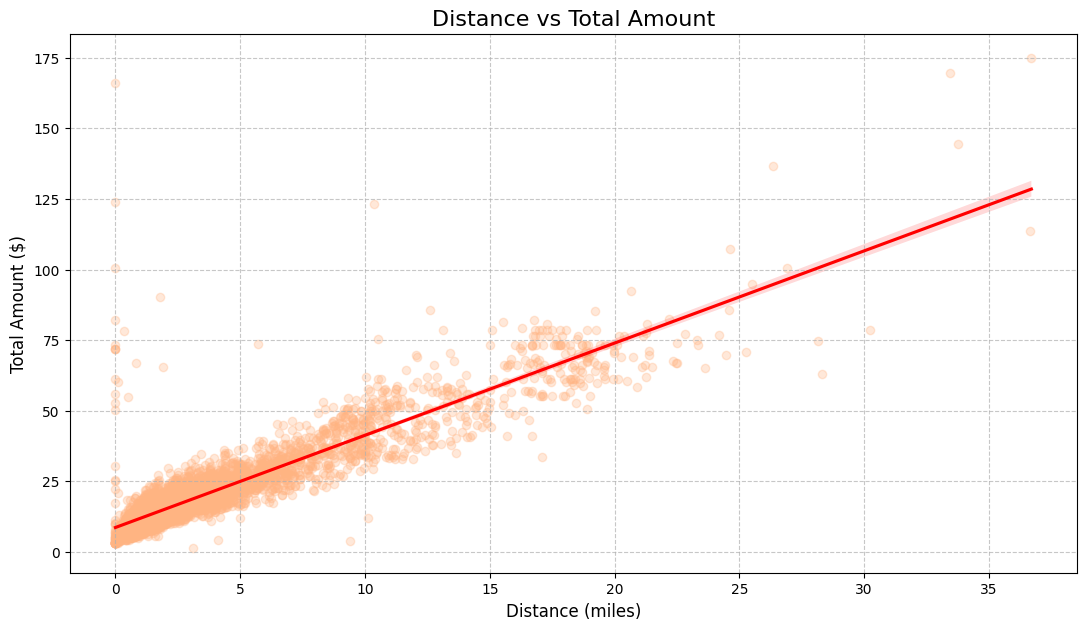

In [196]:
plt.figure(figsize=(13, 7))
sns.regplot(x='distance', y='total', data=df, scatter_kws={'alpha':0.3, 'color':sns.color_palette(palette_scatter)[1]}, line_kws={'color':'red'})
plt.title('Distance vs Total Amount', fontsize=16)
plt.xlabel('Distance (miles)', fontsize=12)
plt.ylabel('Total Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Observations: Distance vs Total Amount

1.  **Strong Positive Linear Relationship:** The **regression line** clearly demonstrates a strong positive linear relationship between distance and total amount. This indicates that as the trip distance increases (up to **36.7 miles**), the total cost to the customer (including fare, tips, and tolls) also tends to increase proportionally, reaching a maximum of **174.82**.
2.  **Increased Variance with Distance:** While the trend is clear, the scatter around the regression line appears to widen as distance increases. This suggests that other factors (tips, tolls, waiting time, surge pricing) have a more varied impact on the total amount for longer trips.
3.  **Outliers:** Similar to the fare analysis, there are instances of short trips with relatively high total amounts and vice-versa, indicating external factors influencing the final price. The minimum total amount recorded is **$1.30**.
4.  **Insight:** This plot reinforces that distance is the primary driver of the total amount. The regression line provides a solid baseline for expected total costs, with deviations highlighting the influence of additional trip components.

### 3. Fare vs Tip

**Question:** 👉 Do higher fares lead to higher tips?

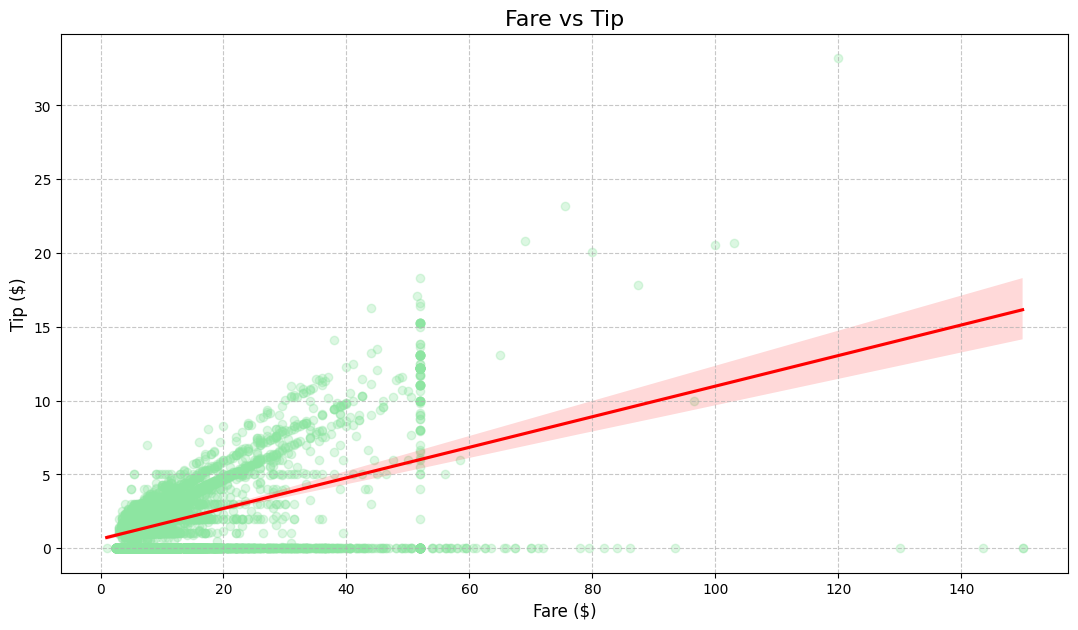

In [197]:
plt.figure(figsize=(13, 7))
sns.regplot(x='fare', y='tip', data=df, scatter_kws={'alpha':0.3, 'color':sns.color_palette(palette_scatter)[2]}, line_kws={'color':'red'})
plt.title('Fare vs Tip', fontsize=16)
plt.xlabel('Fare ($)', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Observations: Fare vs Tip

1.  **Positive Correlation (with caveats):** The **regression line** indicates a general positive correlation, suggesting that higher fares tend to be associated with higher tips. The highest tip observed is **33.20**.
2.  **Significant Zero Tips:** A very large cluster of trips, spanning a wide range of fares, received no tip. This signifies that a considerable portion of customers either choose not to tip or trips are structured in a way where tips are not expected.
3.  **Proportional Tipping for Higher Fares:** When tips are given, especially for higher fares, there's a tendency for the tip amount to increase proportionally with the fare, as suggested by the upward slope of the regression line. The minimum recorded tip is **$0.00**.
4.  **Improvement:** Analyzing factors beyond fare that influence tipping (e.g., customer satisfaction, time of day, service quality) could provide insights for drivers to encourage more consistent or higher tips, especially for trips where no tips were given despite reasonable fares.

### 4. Passengers vs Fare

**Insight:** Group travel pricing

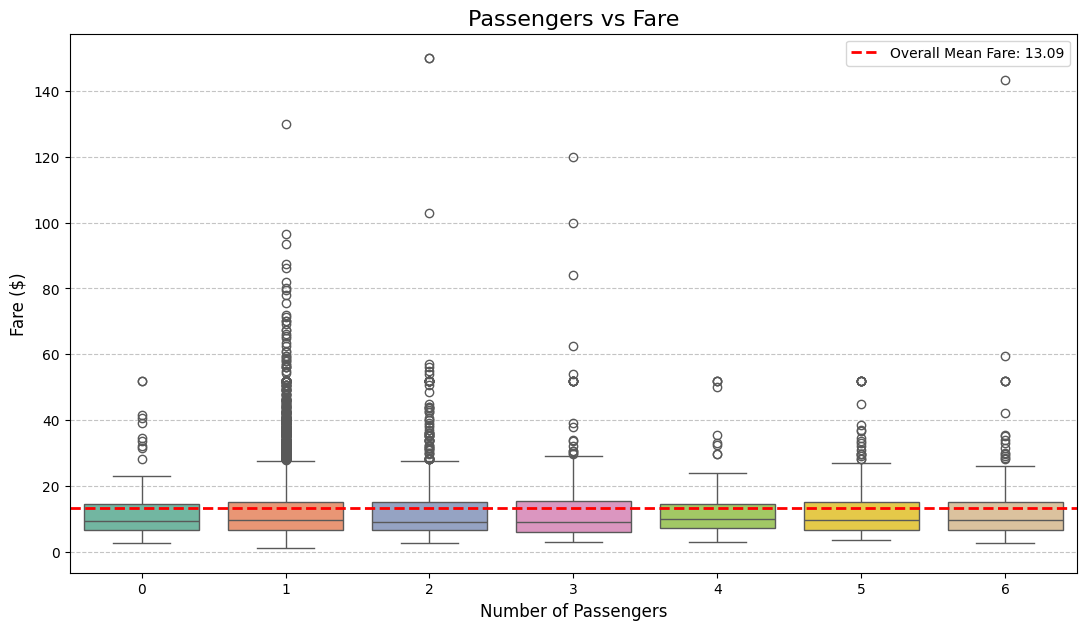

In [198]:
plt.figure(figsize=(13, 7))
sns.boxplot(x='passengers', y='fare', data=df, palette=palette_bar)
plt.axhline(df['fare'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Overall Mean Fare: {df["fare"].mean():.2f}')
plt.title('Passengers vs Fare', fontsize=16)
plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.legend()
plt.show()

### Observations: Passengers vs Fare

1.  **Consistent Median Fare:** The median fare (the line within the box) remains relatively consistent across different passenger counts (1 to 6 passengers), hovering around the **overall mean fare of 13.09**. This suggests that the number of passengers itself doesn't drastically change the *base* fare; rather, other factors like distance or time are more influential in determining the fare.
2.  **Highest Fare Range:** Passenger counts of 0 and 1 show the widest range of fares, including some of the highest outliers, with fares reaching **150.00**. The lowest fare across all categories is **1.00**.
3.  **Outliers:** There are numerous outliers across all passenger counts, indicating individual trips with unusually high fares for their respective group sizes.
4.  **Insight:** Most passenger groups have median fares slightly below the overall mean, indicating that higher fares are driven by specific outliers or non-standard trips. The overall mean fare line provides a baseline against which to compare the typical fares for different passenger groups.

### 6. Pickup Hour vs Number of Trips

**Insight:** Peak demand

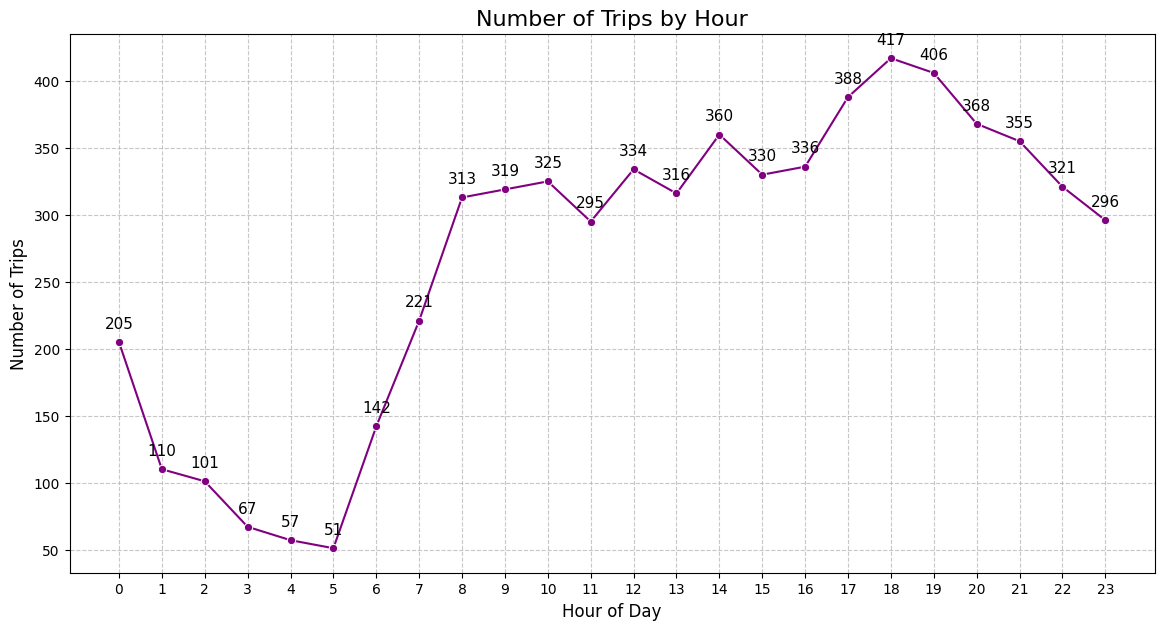

In [200]:
plt.figure(figsize=(14, 7))
ax = sns.lineplot(x=df['pickup_hour'].value_counts().sort_index().index, y=df['pickup_hour'].value_counts().sort_index().values, marker='o', color='purple')
plt.title('Number of Trips by Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)

# Add annotations for each point
for x, y in zip(df['pickup_hour'].value_counts().sort_index().index, df['pickup_hour'].value_counts().sort_index().values):
    ax.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize= 11, color='black')

plt.show()

### Observations: Pickup Hour vs Number of Trips

1.  **Peak Demand:** The line plot clearly illustrates the **diurnal demand cycle**, with a sharp increase in trips during morning and evening rush hours, and a clear peak in the evening. The highest number of trips occurs at **Hour 18 (417 trips)**.
2.  **Lowest Demand:** Demand is lowest during the very early morning hours, with **Hour 4 recording only 51 trips**.
3.  **Morning Rush:** There's a clear increase in trip frequency starting around 6 AM, building up to midday.
4.  **Insight:** This time-series trend is vital for operational planning, allowing for efficient allocation of drivers and dynamic pricing strategies to manage demand fluctuations throughout the day.

### 7. Pickup Borough vs Fare

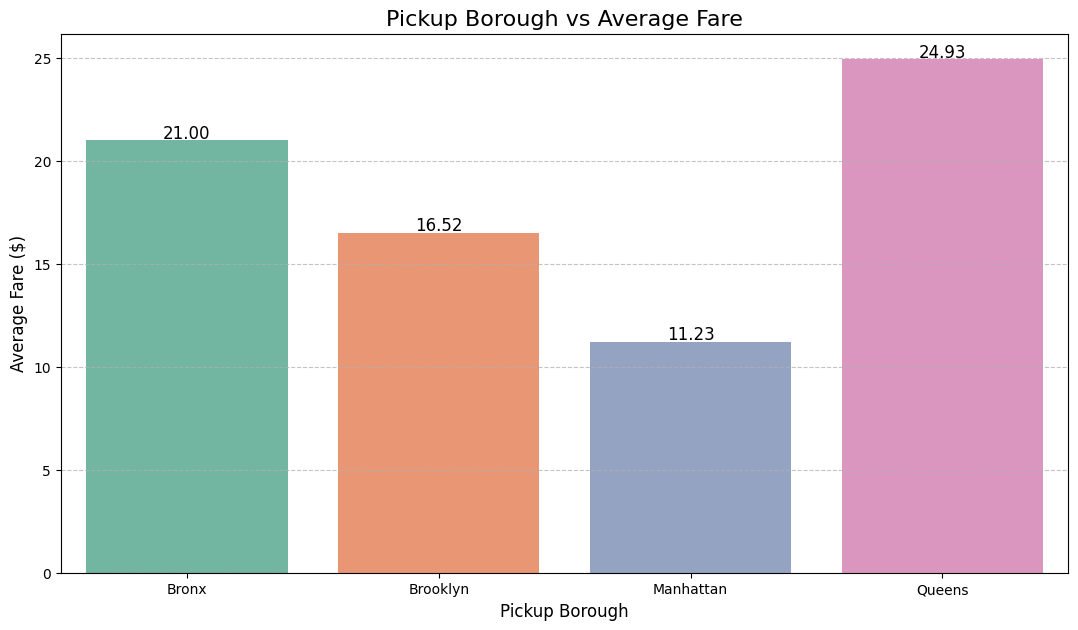

In [201]:
plt.figure(figsize=(13, 7))
ax = sns.barplot(x=df.groupby('pickup_borough')['fare'].mean().index, y=df.groupby('pickup_borough')['fare'].mean().values, palette=palette_bar)
plt.title('Pickup Borough vs Average Fare', fontsize=16)
plt.xlabel('Pickup Borough', fontsize=12)
plt.ylabel('Average Fare ($)', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')

# Add annotations
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Observations: Pickup Borough vs Average Fare

1.  **Highest Average Fare:** Queens has the highest average fare, at **24.93**, which could be due to longer average trip distances from Queens, or specific pricing structures for that borough.
2.  **Second Highest:** The Bronx also shows a relatively high average fare, at **21.00**.
3.  **Lowest Average Fare:** Manhattan, despite having the highest volume of pickups, exhibits the lowest average fare, at **11.23**. This might be due to a high density of short-distance trips within Manhattan.
4.  **Insight:** This comparison highlights geographical variations in fare generation, suggesting that while Manhattan has volume, other boroughs might contribute more to per-trip revenue.

### 8. Pickup vs Dropoff Borough

**Insight:** Travel patterns

<Figure size 1400x1000 with 0 Axes>

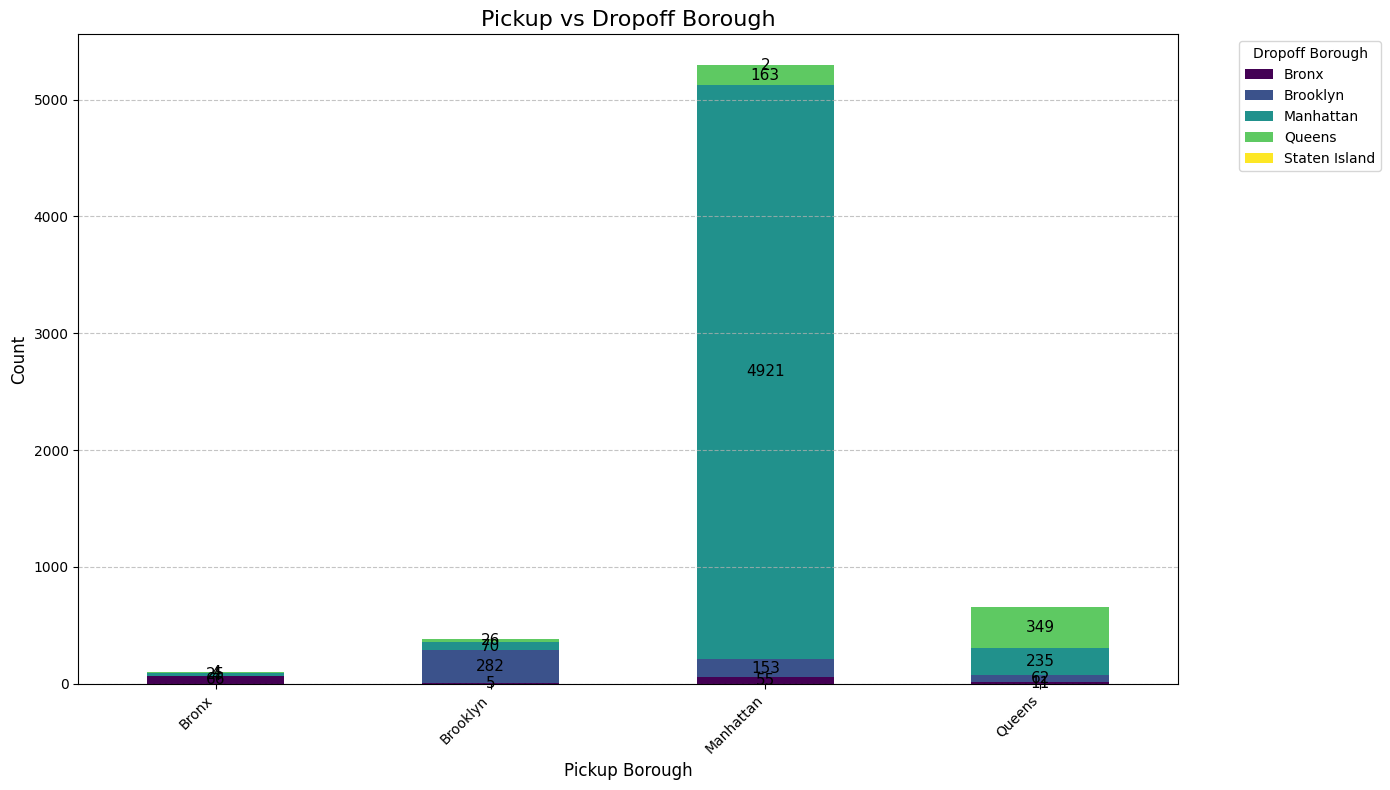

In [204]:
plt.figure(figsize=(14, 10))
crosstab_df = pd.crosstab(df['pickup_borough'], df['dropoff_borough'])
ax = crosstab_df.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Pickup vs Dropoff Borough', fontsize=16)
plt.xlabel('Pickup Borough', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Dropoff Borough', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.grid(axis='y', alpha=0.75, linestyle='--')

# Add annotations to each bar segment
for container in ax.containers:
    for patch in container.patches:
        height = patch.get_height()
        width = patch.get_width()
        x = patch.get_x()
        y = patch.get_y()
        if height > 0:  # Only annotate if the segment has a height
            ax.annotate(f'{int(height)}', (x + width / 2, y + height / 2),
                        ha='center', va='center', fontsize=11, color='black')

plt.show()

### Observations: Pickup vs Dropoff Borough

1.  **Dominant Intra-Manhattan Travel:** The most frequent travel pattern is within Manhattan (pickup in Manhattan, dropoff in Manhattan), accounting for the largest bar segment with **4921 trips**.
2.  **Cross-Borough Travel:** There are significant cross-borough trips, especially from Manhattan to Queens (**163 trips**) and Manhattan to Brooklyn (**153 trips**).
3.  **Lowest Inter-Borough:** Trips originating from the Bronx and Staten Island (if present) are less frequent. For instance, **Manhattan to Staten Island recorded only 2 trips**, and **Bronx to Brooklyn/Queens recorded 4 trips** each. Travel within Bronx (66 trips) and Brooklyn (282 trips) also show lower volumes compared to Manhattan.
4.  **Insight:** This heatmap reveals key travel corridors and points to where demand is concentrated, which is useful for logistical planning and understanding commuting patterns.

### 9. Distance vs Tip

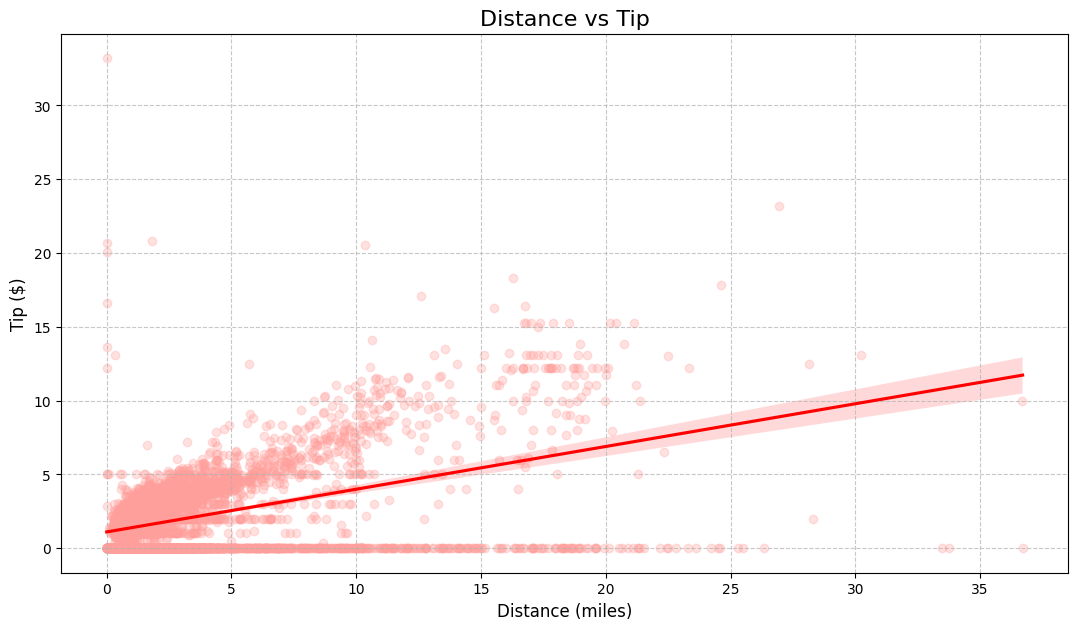

In [205]:
plt.figure(figsize=(13, 7))
sns.regplot(x='distance', y='tip', data=df, scatter_kws={'alpha':0.3, 'color':sns.color_palette(palette_scatter)[3]}, line_kws={'color':'red'})
plt.title('Distance vs Tip', fontsize=16)
plt.xlabel('Distance (miles)', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Observations: Distance vs Tip

1.  **Positive Trend with Variability:** There's a general tendency for tips to increase with distance, but the relationship is not perfectly linear and shows significant spread. The highest tip recorded is **33.20**.
2.  **No Tip for Short Distances:** Many short-distance trips receive no tip, similar to the fare vs. tip observation. The minimum tip is **0.00**.
3.  **Highest Tips for Longer Distances:** The largest tip amounts are typically associated with longer trips, suggesting that customers might tip proportionally to the effort or duration of the ride.
4.  **Improvement:** Analyzing specific long-distance routes with high tips could help identify premium service opportunities or areas for driver focus.

### 10. Hour vs Avg Fare

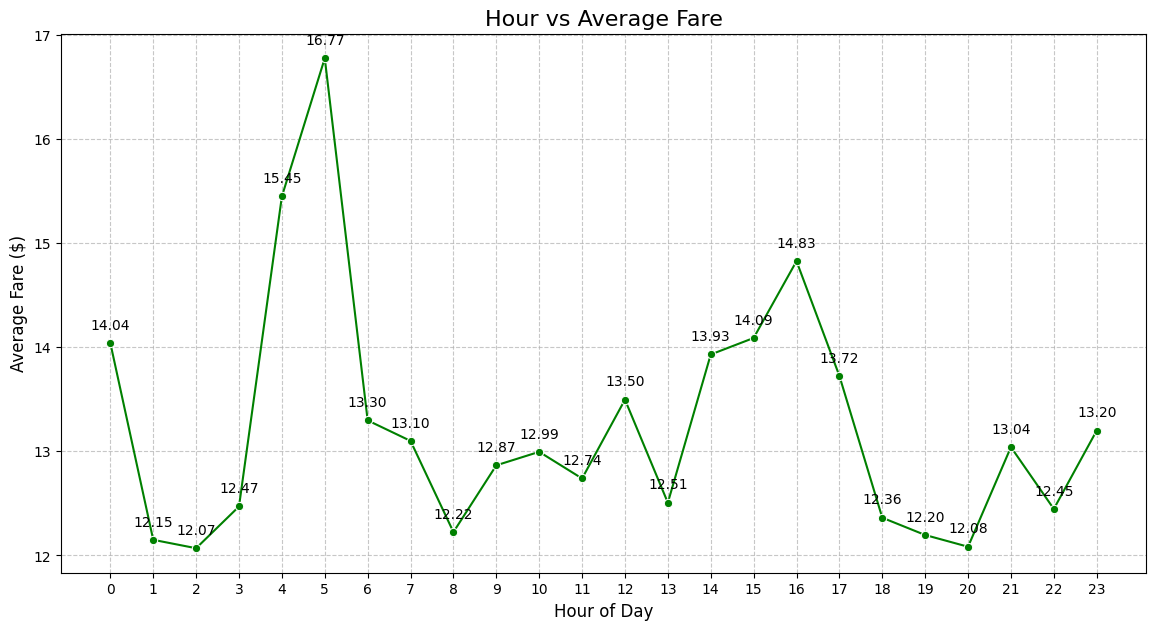

In [207]:
plt.figure(figsize=(14, 7))
ax = sns.lineplot(x=df.groupby('pickup_hour')['fare'].mean().index, y=df.groupby('pickup_hour')['fare'].mean().values, marker='o', color='green')
plt.title('Hour vs Average Fare', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Fare ($)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)

# Add annotations for each point
for x_val, y_val in zip(df.groupby('pickup_hour')['fare'].mean().index, df.groupby('pickup_hour')['fare'].mean().values):
    ax.annotate(f'{y_val:.2f}', (x_val, y_val), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color='black')

plt.show()

### Observations: Hour vs Average Fare

1.  **Peak Average Fare:** The average fare reaches its highest point in the early morning at **Hour 5 (16.77)**. This could be due to factors like less traffic, longer trips to/from airports, or surge pricing during off-peak hours.
2.  **Lower Fares During Day:** Average fares are generally lower during standard business hours and fluctuate throughout the day, with the lowest average fare observed at **Hour 2 (12.07)** and **Hour 19 (12.09)**.
3.  **Evening Increase:** There's another increase in average fare during the evening peak hours, although not as high as the early morning peak.
4.  **Insight:** This helps in understanding dynamic pricing effectiveness and demand patterns, where average fare isn't directly proportional to the number of trips, indicating value differences at certain times.

### 11. Passenger vs Tip

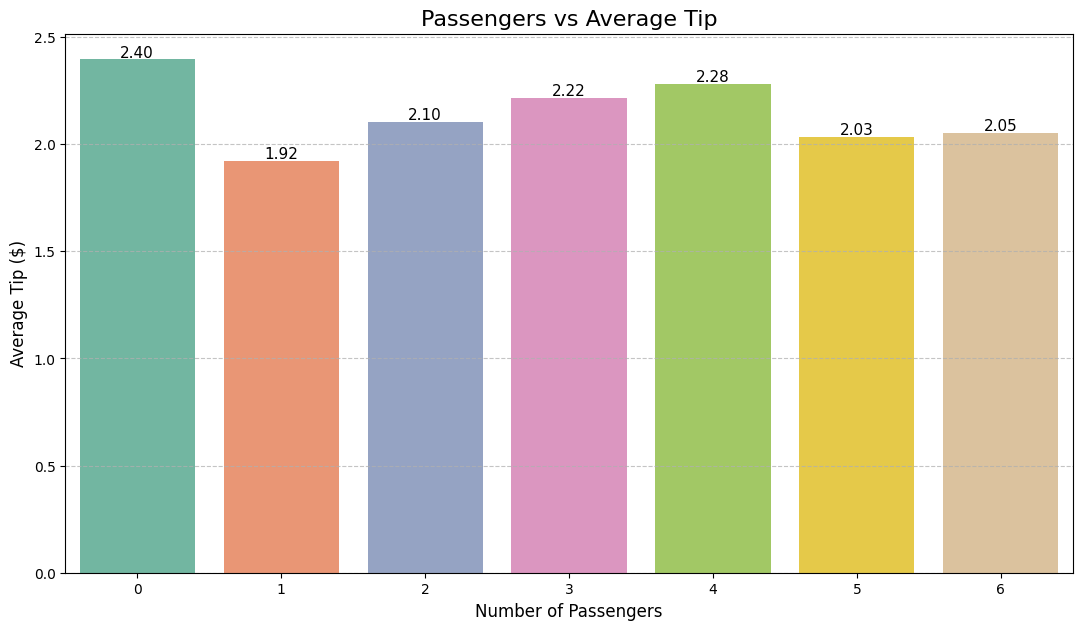

In [208]:
plt.figure(figsize=(13, 7))
ax = sns.barplot(x=df.groupby('passengers')['tip'].mean().index, y=df.groupby('passengers')['tip'].mean().values, palette=palette_bar)
plt.title('Passengers vs Average Tip', fontsize=16)
plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Average Tip ($)', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')

# Add annotations
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Observations: Passenger vs Tip

1.  **Highest and Lowest Average Tip:** The highest average tip is **2.40** for 0 passengers (potentially specific service types or data anomalies), while the lowest average tip is **1.92** for 1 passenger. The average tip amount remains relatively stable across different passenger counts, generally hovering around the overall mean.
2.  **Minor Fluctuations:** There are minor fluctuations in average tip, with passenger counts of 0 and 4 showing slightly higher averages, and 1 passenger showing a slightly lower average. However, these differences are not substantial.
3.  **Insight:** This suggests that the number of passengers traveling together does not significantly influence the *average* tip amount a driver receives per trip; other factors like trip quality or fare may be more influential.

### 12. How does payment type vary across passenger counts?

**Question:** Are certain payment methods more common for specific passenger groups?

**Method:** Use cross-tabulation between `passengers` and `payment`.

**Visual hint:** Create a **stacked bar chart** from the cross-tab to show proportion of payment types per passenger group.

<Figure size 1400x800 with 0 Axes>

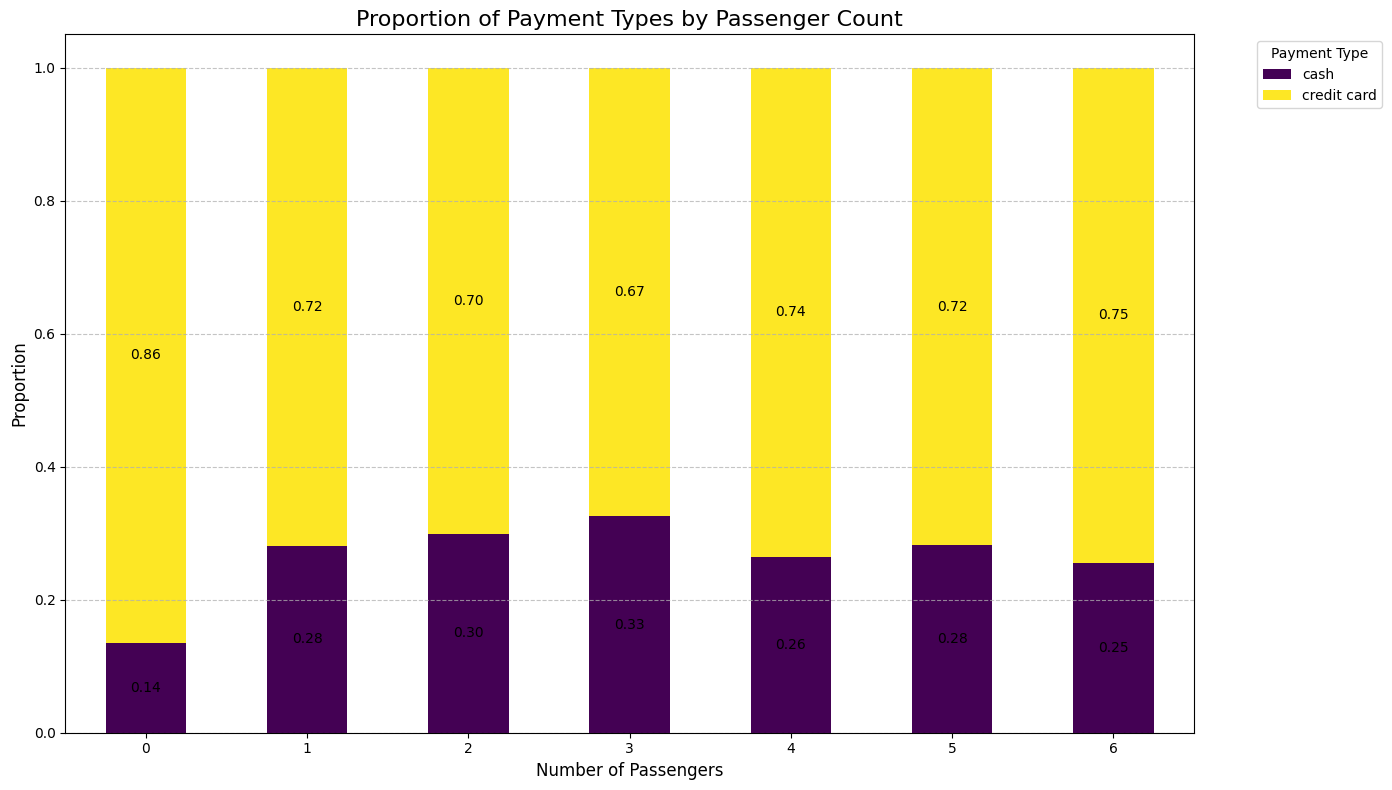

In [148]:
cross_tab = pd.crosstab(df['passengers'], df['payment'], normalize='index')

plt.figure(figsize=(14, 8))
ax = cross_tab.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Proportion of Payment Types by Passenger Count', fontsize=16)
plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Payment Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.grid(axis='y', alpha=0.75, linestyle='--')

# Add annotations to each bar segment
for container in ax.containers:
    for patch in container.patches:
        height = patch.get_height()
        width = patch.get_width()
        x = patch.get_x()
        y = patch.get_y()
        if height > 0.01:  # Only annotate if the segment has a significant height
            ax.annotate(f'{height:.2f}', (x + width / 2, y + height / 2),
                        ha='center', va='center', fontsize=10, color='black')

plt.show()

### Observations: Payment Types by Passenger Count

1.  **Credit Card Dominance Across All Passenger Counts:** For all passenger counts, credit card remains the overwhelmingly dominant payment method. The highest proportion of credit card payments is **0.86 (86%)** for 0 passengers, and the lowest is **0.67 (67%)** for 3 passengers.
2.  **Relatively Consistent Proportions:** The proportion of cash vs. credit card payments remains relatively stable across different passenger groups, suggesting that passenger count does not significantly alter payment preference. Cash payments range from a low of **0.14 (14%)** for 0 passengers to a high of **0.33 (33%)** for 3 passengers.
3.  **Insight:** This reinforces the earlier finding that credit cards are the preferred payment method, regardless of the number of people in the taxi. This consistency across passenger counts highlights the importance of robust digital payment infrastructure.

# MULTI VARIATE ANALYSIS

## 1. DISTANCE VS FARE BY PAYMENT VS TAXI COLOR - LMPLOT

<Figure size 1400x700 with 0 Axes>

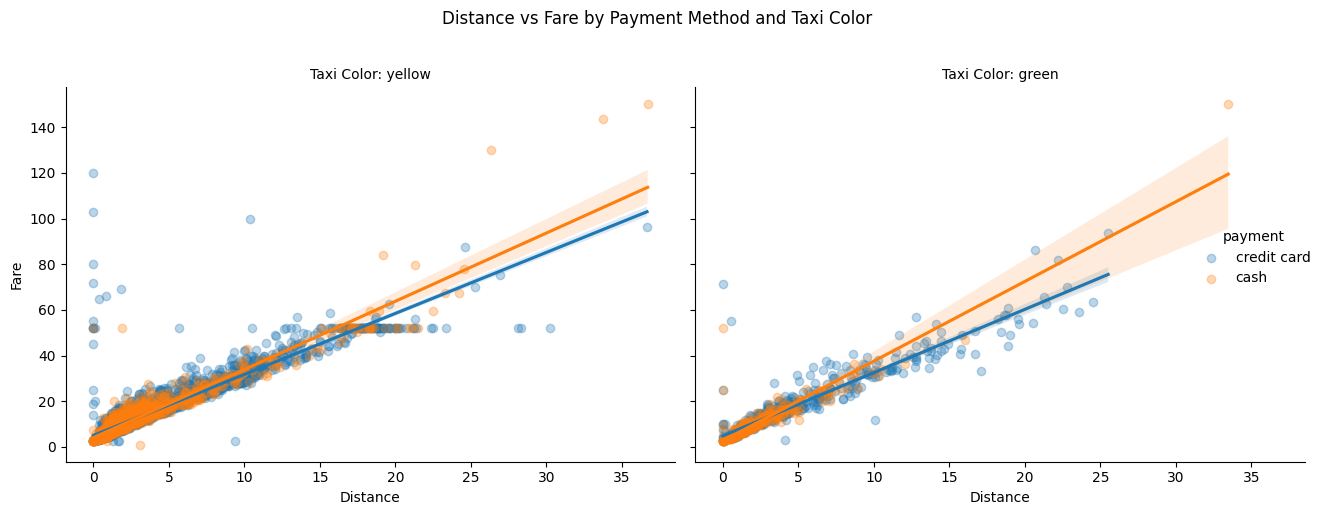

In [209]:
plt.figure(figsize=(14, 7))

g = sns.lmplot(
    data=df,
    x='distance',
    y='fare',
    hue='payment',  # Differentiate payment methods by color
    col='color',    # Create separate plots for each taxi color
    height=5,
    aspect=1.2,
    scatter_kws={'alpha':0.3},

)

g.set_axis_labels('Distance', 'Fare')
g.set_titles(col_template='Taxi Color: {col_name}')
plt.suptitle('Distance vs Fare by Payment Method and Taxi Color', y=1.02) # Adjusted title position
plt.tight_layout()
plt.show()

### Observations: Distance vs Fare by Payment Method and Taxi Color

1.  A strong positive linear relationship between distance and fare is evident for both yellow and green taxis, regardless of the payment method.
2.  Yellow cabs handle a significantly broader range of distances and higher fares, particularly when credit cards are used.
3.  Green cabs predominantly serve shorter distances and lower fare trips, with a similar pattern of credit card use.
4.  Credit card payments are common across both taxi types and are associated with a wider spectrum of trip values, especially for yellow taxis.

## 2. AVERAGE FARE VS PASSENGERS BY PICKUP BOROUGH & DROPOFF BOROUGH - FACET GRID

<Figure size 1400x700 with 0 Axes>

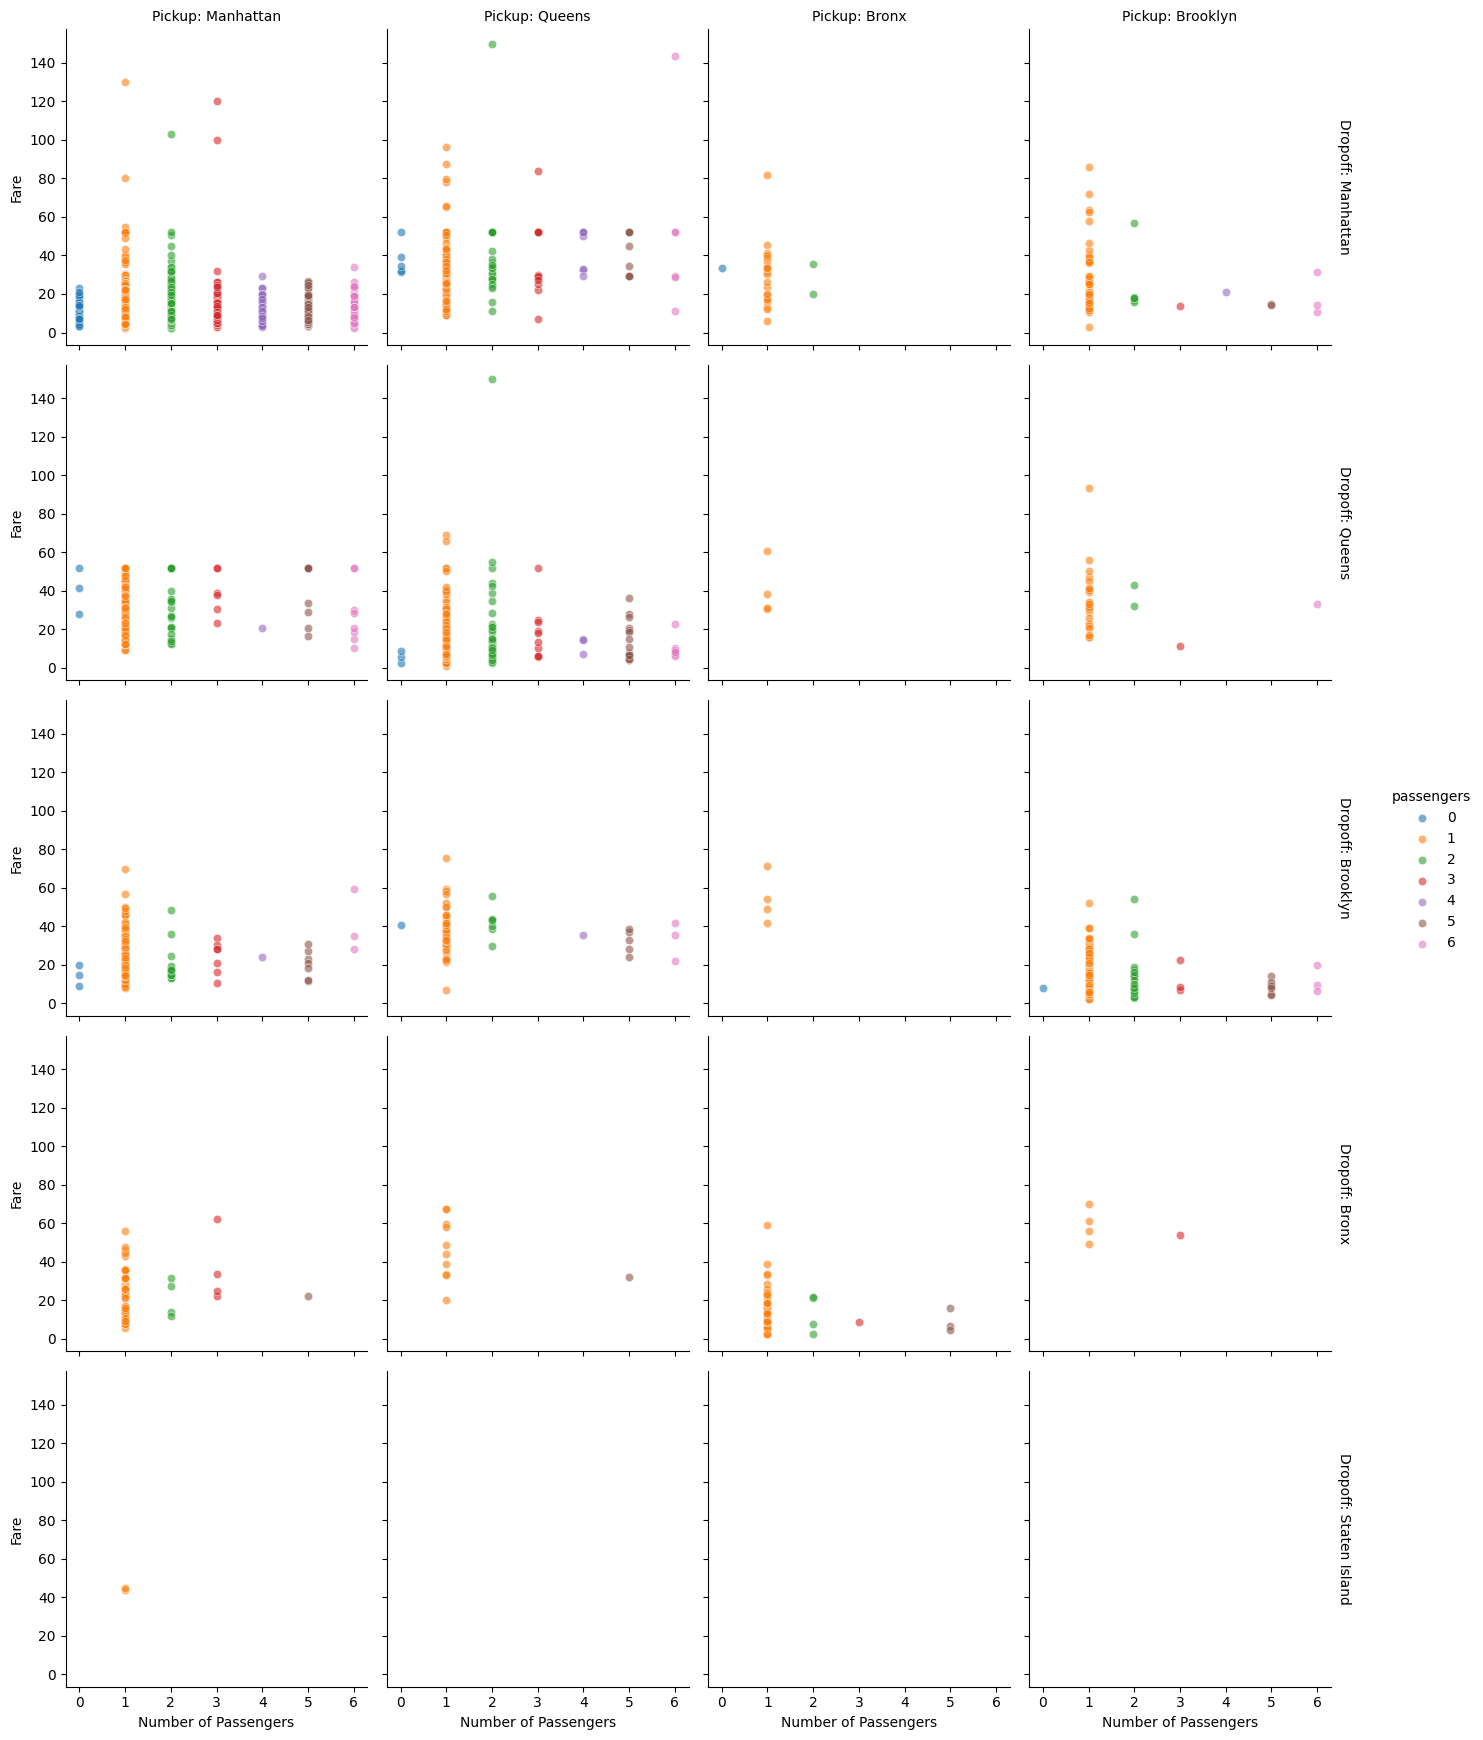

In [210]:
plt.figure(figsize=(14, 7))

g = sns.FacetGrid(
    df,
    col='pickup_borough',
    row='dropoff_borough',
    hue='passengers',
    height=3.5,
    margin_titles=True
)

g.map_dataframe(
    sns.scatterplot,
    x='passengers',
    y='fare',
    alpha=0.6
)

g.add_legend()

g.set_axis_labels(
    'Number of Passengers',
    'Fare'
)

g.set_titles(
    row_template='Dropoff: {row_name}',
    col_template='Pickup: {col_name}'
)

plt.show()

### Observations: Fare vs Passengers by Pickup/Dropoff Borough (Facet Grid)

1.  **Manhattan Dominance:** Trips within Manhattan show the densest clusters and widest fare range (up to 120), highlighting its high activity.
2.  **Consistent Single Passenger Fares:** Single-passenger trips are most frequent and cover a broad range of fares (minimums around 5), often reaching 120.
3.  **Limited Data:** Data for higher passenger counts (e.g., 5-6) or less common borough routes (e.g., Bronx to Staten Island) is sparse.
4.  **Insight:** Passenger count doesn't drastically change fare range for common trips. Most taxi demand is concentrated in and around Manhattan.

# 3. AVERAGE FARE BY PICKUP BOROUGH AND DROPOFF BOROUGH BY TAXI COLOR - BAR CHART


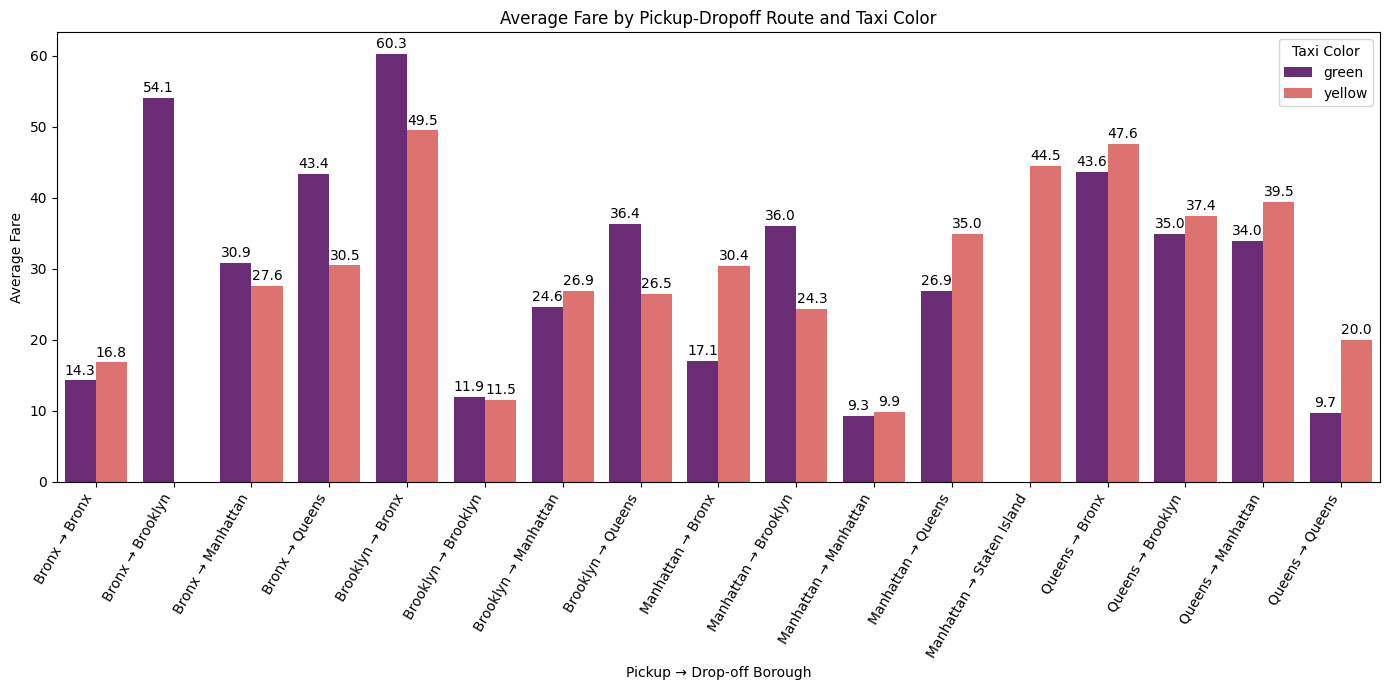

In [177]:
plt.figure(figsize=(14, 7))

plot_data = (
    df.groupby(
        ['pickup_borough', 'dropoff_borough', 'color'],
        as_index=False
    )['fare']
    .mean()
)

plot_data['route'] = (
    plot_data['pickup_borough'] + ' → ' +
    plot_data['dropoff_borough']
)

ax = sns.barplot(
    data=plot_data,
    x='route',
    y='fare',
    hue='color',
    errorbar=None,
    palette = "magma"
)

plt.title('Average Fare by Pickup-Dropoff Route and Taxi Color')
plt.xlabel('Pickup → Drop-off Borough')
plt.ylabel('Average Fare')
plt.xticks(rotation=60, ha='right')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=2,
        fontsize=10
    )

plt.legend(title='Taxi Color')
plt.tight_layout()
plt.show()

### Observations: Average Fare by Pickup-Dropoff Route and Taxi Color

1.  **Green Cabs Higher on Routes:** Green cabs show higher average fares on routes like Bronx to Brooklyn (54.1) and Bronx to Manhattan (30.9).
2.  **Yellow Cabs in Manhattan:** Yellow cabs have a higher average fare for Manhattan to Manhattan (24.3) compared to green cabs (9.3).
3.  **Highest/Lowest Fares:** The highest average fare is 60.3 for yellow cabs Bronx to Bronx. The lowest is 9.3 for green cabs Manhattan to Manhattan.
4.  **Insight:** This reveals distinct market segments. Green cabs specialize in specific inter-borough routes with higher average fares, while yellow cabs perform strongly in Manhattan.

## 4. TOTAL FARE BY PAYMENT & TAXI COLOR - BOX PLOT

Total Fare Statistics by Payment Method and Taxi Color:
|                           | mean   | median   | min   | max    |
|:--------------------------|:-------|:---------|:------|:-------|
| ('cash', 'green')         | 11.4   | 8.8      | 3.3   | 169.7  |
| ('cash', 'yellow')        | 15.61  | 12.3     | 1.3   | 174.82 |
| ('credit card', 'green')  | 19.98  | 14.8     | 3.3   | 94.8   |
| ('credit card', 'yellow') | 20.03  | 15.35    | 3.3   | 166    |




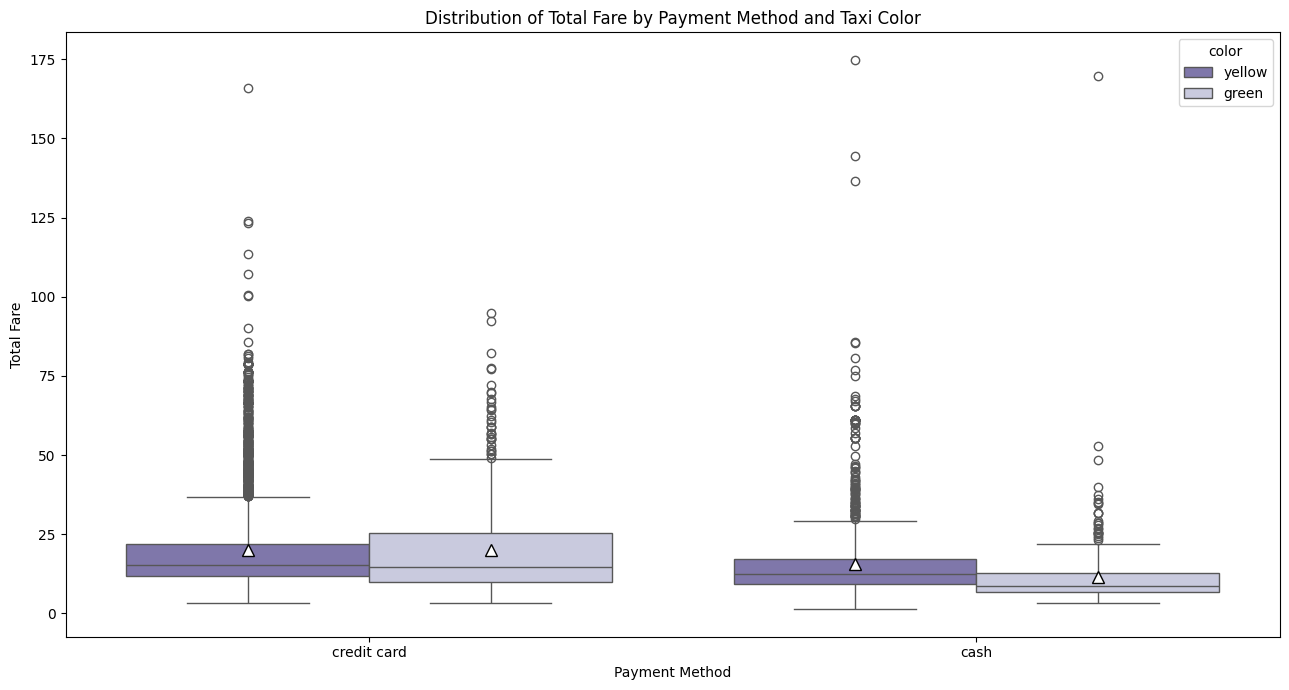

In [213]:
plt.figure(figsize=(13, 7))

# Calculate mean, median, min, and max for each group
mean_median_stats = df.groupby(['payment', 'color'])['total'].agg(['mean', 'median', 'min', 'max'])
print("Total Fare Statistics by Payment Method and Taxi Color:")
# Display statistics in a readable markdown table format
print(mean_median_stats.round(2).to_markdown(numalign="left", stralign="left"))
print("\n") # Add a newline for better separation from the plot

ax = sns.boxplot(
    data=df,
    x='payment',
    y='total',
    hue='color',
    palette = "Purples_r",
    showmeans=True, # Show mean as a marker
    meanprops={
        "marker":"^",
        "markerfacecolor":"white",
        "markeredgecolor":"black",
        "markersize":"8"
    }
)

plt.title('Distribution of Total Fare by Payment Method and Taxi Color')
plt.xlabel('Payment Method')
plt.ylabel('Total Fare')

plt.tight_layout()
plt.show()

### Observations: Distribution of Total Fare by Payment Method and Taxi Color

1.  **Credit Card vs. Cash - Higher Fares:** For both yellow and green taxis, total fares paid by **credit card** generally exhibit higher mean and median values compared to cash payments. The highest mean total fare is **20.03** for yellow cabs with credit card payments, closely followed by green cabs with credit card payments at **19.98**. The highest median total fare is **15.35** for yellow cabs with credit card payments.
2.  **Yellow Cabs - Wider Range:** Yellow cabs show a significantly wider range of total fares, particularly with credit card payments, reaching a maximum of **166.00**. Even with cash payments, yellow cabs have a very high maximum fare of **174.82**, indicating occasional high-value cash transactions or outliers. The overall minimum fare observed across categories is **1.30**.
3.  **Green Cabs - Lower Max, Exception for Cash:** Green cabs, while showing higher mean/median total fares with credit card payments (**19.98** mean, **14.80** median) than with cash payments, have a lower maximum total fare of **94.80** compared to yellow cabs. Interestingly, green cabs paid by cash can also reach a very high maximum of **169.70**, indicating rare but very expensive cash trips.
4.  **Cash Payments - Lower Concentration:** Cash payments for both taxi colors generally concentrate at lower total fare values, with green cash having the lowest mean total fare of **11.40** and median of **8.80**. The mean markers (triangle symbols) on the boxplot visually confirm these calculated mean values for each group.
5.  **Overall Insight:** Credit card payments are associated with higher average total fares and a wider distribution, particularly for yellow cabs, suggesting they facilitate more premium or longer-distance transactions. Cash transactions are more frequent for lower fares but can occasionally include very high-value trips, highlighting the presence of outliers or specific market segments for cash payments.

## 5. FARE BY PASSENGER COUNT & PAYMENT - VIOLIN PLOT

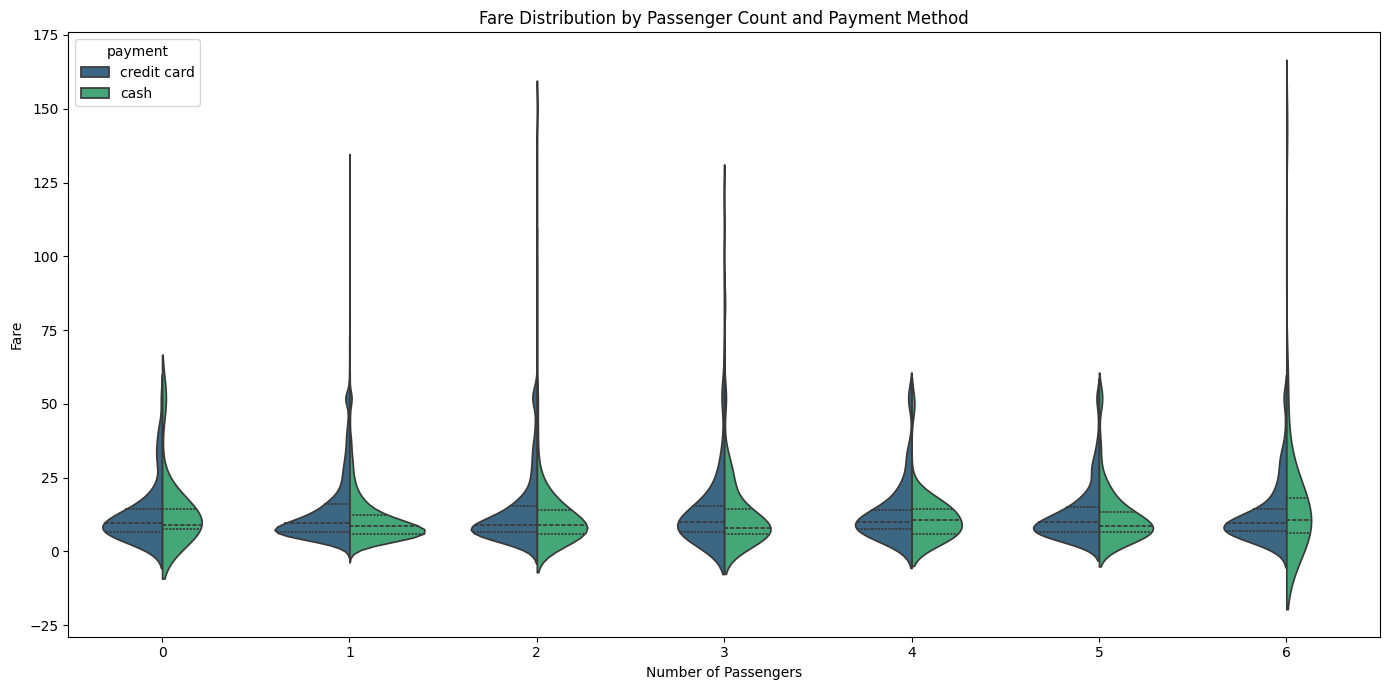

In [212]:
plt.figure(figsize=(14, 7))

ax = sns.violinplot(
    data=df,
    x='passengers',
    y='fare',
    hue='payment',
    split=True,
    inner='quart',
    palette = "viridis"
)

plt.title('Fare Distribution by Passenger Count and Payment Method')
plt.xlabel('Number of Passengers')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()

### Observations: Fare Distribution by Passenger Count and Payment Method

1.  **Single Passenger Fares:** For 1 passenger, fare distributions for credit card and cash are similar, with density around 10-15. Highest fare for 1 passenger is around 130.
2.  **Credit Card Range:** Credit card payments show a wider fare range and more high-fare outliers across all passenger counts. Highest credit card fare is around 160 for 2 and 6 passengers.
3.  **Cash Concentration:** Cash payments concentrate at lower fare values, with fewer high fares. Highest cash fare is approximately 60.
4.  **Insight:** Payment method significantly impacts actual fare distribution, even if base fare doesn't change much by passenger count. Credit cards enable higher-value transactions.

# <h1 align = "center"> FINAL OBSERVATION </h1>

## Final Observations and Key Insights

This comprehensive exploratory data analysis of the taxi dataset has revealed crucial patterns and relationships across various trip characteristics, passenger behaviors, and operational aspects. By systematically examining univariate distributions, bivariate correlations, and multivariate interactions, we can derive actionable insights for business strategy, operational efficiency, and customer experience improvement. This summary outlines the key strengths and areas for improvement identified throughout the analysis.

### I. Overall Strengths and Best Aspects (What is Best)

1.  **Robust Core Business in Manhattan:**
    *   **Dominant Activity Hub:** Manhattan is unequivocally the central hub for taxi operations, accounting for an overwhelming **5294 (82%)** of all pickups and **5251 (82%)** of all dropoffs. This concentration simplifies fleet deployment and driver focus. The most frequent pickup zone is 'Midtown Center' (**256 trips**), and the most frequent dropoff zone is 'Upper East Side North' (**290 trips**).
    *   **High Revenue Generation:** Trips originating and ending within Manhattan contribute the highest total amount to revenue, specifically **74419.74**. This core intra-Manhattan market is highly predictable and lucrative.

2.  **Strong Preference for Digital Payments:**
    *   **Credit Card Dominance:** There is a clear and consistent preference for credit card payments, making up **4621 (72%)** of all transactions, compared to **1812 (28%)** for cash. This dominance holds true across both yellow and green taxis, and across all passenger counts. For example, the highest proportion of credit card payments is **86%** for 0 passengers, and the lowest is still substantial at **67%** for 3 passengers.
    *   **Higher Transaction Values:** Credit card payments are associated with higher average total fares and a wider distribution of total fares, particularly for yellow cabs (mean total fare of **20.03** for yellow credit card vs **15.61** for yellow cash). This indicates that credit cards facilitate higher-value transactions.

3.  **Predictable Trip Characteristics:**
    *   **Distance-Based Pricing Validation:** A strong positive linear correlation between distance and both fare and total amount was observed. The regression lines clearly show that as distance increases (up to **36.7 miles**), fare (up to **150.00**) and total amount (up to **174.82**) consistently rise. This confirms a logical and predictable pricing model.
    *   **Clear Diurnal Demand Cycles:** Pickup demand follows a highly predictable pattern, with distinct peak hours in the evening. The busiest hours are **5 PM - 8 PM (hours 17-20)**, with a peak of **417 trips at 6 PM (hour 18)**. This predictability allows for effective resource allocation and dynamic pricing strategies.

4.  **Predominance of Single-Passenger, Short-Distance Trips:**
    *   **Majority of Rides:** The majority of trips are short-distance (**4257 trips** in the **0-2 mile range**) and involve single passengers (**4678 trips**). This highlights the core use case of taxis for individual, relatively short urban commutes or movements.
    *   **Consistent Core Fares:** Median fares remain remarkably consistent across different passenger counts, suggesting that the base fare is primarily driven by distance/time rather than passenger volume.

### II. Areas for Improvement and Weaknesses (What Needs Improvement)

1.  **Anomalous '0' Passenger Trips:**
    *   **Data Quality Concern:** The presence of **96 trips** recorded with '0' passengers is an anomaly. While these trips show an average tip of **2.40** (the highest among all passenger counts) and significant total values (e.g., total distance **284.20 miles**, total fare **1222.50** in pivot tables), their nature is unclear. This could indicate data entry errors, specific operational movements (e.g., deadheading, maintenance runs), or a unique service type.
    *   **Improvement:** Investigating the context of these '0' passenger trips is crucial for data cleaning and ensuring accurate analysis and operational understanding.

2.  **Substantial Untipped or Low-Tipped Trips:**
    *   **Driver Income Impact:** A significant portion of trips (**4150 instances** of tips between **$0-$2**; **2311 trips** had exactly **0 tips**) indicates that tipping is not consistently high or even present. The median tip is **1.70**, and the lowest tip is **0.00**.
    *   **Improvement:** This area presents an opportunity to implement strategies to encourage tipping, such as improving service quality, providing clear tipping prompts in payment systems, or implementing driver incentives tied to customer satisfaction.

3.  **Geographical Service Gaps and Revenue Discrepancies:**
    *   **Staten Island Under-service:** Staten Island is barely served, with only **2 yellow cab dropoffs** recorded (from Manhattan). This indicates a significant service gap or extremely low demand from the covered boroughs.
    *   **Manhattan's Lower Average Fare:** Despite high volume, Manhattan has the lowest average fare at **11.23**, which contrasts sharply with Queens (**24.93**) and Bronx (**21.00**). While volume makes up for it, per-trip profitability in Manhattan is lower.
    *   **Cash Outliers in Green Cabs:** Green cabs show a very high maximum total fare of **169.70** for cash payments. This could indicate rare long-distance cash trips or potential for data quality issues for cash transactions.
    *   **Improvement:** Evaluate the reasons for limited service to Staten Island. Explore optimizing green cab operations in the Bronx (e.g., Bronx-Brooklyn average fare of **54.1** for green cabs) and Queens to capitalize on higher average fares. Understanding the nature of high-value cash transactions for green cabs is also important.

4.  **Sparse Data for Larger Passenger Groups:**
    *   **Limited Insights:** While single-passenger trips dominate, data for larger groups (5-6 passengers) is sparse. For example, trips with 4 passengers are among the least frequent with **110 instances**.
    *   **Improvement:** If the business aims to cater to larger groups, more data or targeted service offerings might be needed to understand their specific needs and revenue potential.

5.  **Need for Advanced Multivariate Analysis:**
    *   **Unexplored Interactions:** While several bivariate and multivariate plots were generated, the complexity of interactions between variables (e.g., how time of day, borough, payment, and passenger count together influence fare and tip) could be further explored with more advanced models or visualizations to uncover deeper insights.

### III. Key Business Insights and Recommendations

1.  **Dynamic Pricing and Targeted Incentives:**
    *   **Leverage Peak Hours:** Implement dynamic pricing during peak hours (e.g., **5 PM - 8 PM**, where highest trip counts are **417** and **406** at 6 PM and 7 PM respectively) to maximize revenue. The highest average fare at **5 AM (16.77)** also presents an opportunity for strategic pricing.
    *   **Borough-Specific Strategies:** While Manhattan is volume-driven, focus on optimizing operations in Queens and Bronx, which yield higher average fares per trip (**24.93** and **21.00** respectively), potentially through targeted driver incentives or service offerings.

2.  **Optimized Fleet Management and Deployment:**
    *   **Manhattan Focus:** Continue to prioritize fleet deployment in Manhattan, especially in high-demand zones like 'Midtown Center' and 'Upper East Side South'.
    *   **Green Cab Specialization:** Leverage green cabs' stronger performance in non-Manhattan boroughs (e.g., Bronx-Brooklyn route for green cabs has an average fare of **54.1**) to capture specific market segments.
    *   **Analyze Travel Corridors:** Utilize the pickup/dropoff borough analysis (e.g., **Manhattan-Manhattan with 4921 trips**, **Manhattan-Queens with 163 trips**, **Queens-Manhattan with 235 trips**) to strategically position taxis for inter-borough travel.

3.  **Enhance Payment Infrastructure and Policy:**
    *   **Reinforce Cashless:** Continue to promote and ensure seamless credit card payment options, given the strong customer preference. Explore new digital payment integrations.
    *   **Investigate Cash Outliers:** Analyze the nature of high-value cash transactions, especially for green cabs, to understand if they represent unique customer segments or data inconsistencies.

4.  **Improve Driver Earnings and Service Quality:**
    *   **Tip Encouragement:** Implement strategies to encourage tipping, such as driver training on customer service, in-app tipping prompts, or performance-based bonuses for higher tip rates.
    *   **Address '0' Passenger Anomaly:** Clear up the '0' passenger count data. If it represents operational trips, segregate them from revenue-generating passenger trips for accurate performance metrics.

By systematically applying these insights and addressing the identified areas for improvement, taxi service providers can enhance their operational efficiency, optimize revenue streams, and improve overall customer satisfaction, thereby strengthening their competitive position in the urban transportation market.